In [2]:
# Cell 2: Environment Setup and Dependencies
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import pickle
import random
from tqdm.auto import tqdm

# Signal processing
from scipy.signal import butter, filtfilt, resample, welch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

# Transformers
from transformers import DistilBertTokenizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Evaluation
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
print(f"🔢 PyTorch version: {torch.__version__}")
print(f"🧮 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📊 GPU: {torch.cuda.get_device_name(0)}")

🖥️  Device: cuda
🔢 PyTorch version: 2.8.0+cu128
🧮 CUDA available: True
📊 GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
import subprocess, sys
 
def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
 
try:
    import pennylane as qml
    print(f"✅ PennyLane already installed: {qml.__version__}")
except ImportError:
    print("Installing pennylane + lightning.qubit …")
    _pip("pennylane")
    _pip("pennylane-lightning")   # ~5× faster than default.qubit on CPU
    import pennylane as qml
    print(f"✅ PennyLane installed: {qml.__version__}")
 
# Smoke-test: one qubit, one gate
_dev_smoke = qml.device("lightning.qubit", wires=1)
 
@qml.qnode(_dev_smoke, interface="torch")
def _smoke(x):
    qml.RY(x[0], wires=0)
    return qml.expval(qml.PauliZ(0))
 
import torch
_out = _smoke(torch.tensor([0.5]))
print(f"✅ Smoke-test passed — PauliZ expval = {_out.item():.4f}  (expect ~0.8776)")

✅ PennyLane already installed: 0.44.1
✅ Smoke-test passed — PauliZ expval = 0.8776  (expect ~0.8776)


In [4]:
class Config:
    # Data — loaded from 3 separate condition pickles
    NR_PKL  = "NR_data.pkl"
    TSR_PKL = "TSR_data.pkl"
    SR_PKL  = "SR_data.pkl"

    ORIG_FS          = 500
    TARGET_FS        = 64
    MAX_SECONDS      = 10
    TARGET_LEN       = int(TARGET_FS * MAX_SECONDS)   # 256
    N_PCA_COMPONENTS = 24
    N_CHANNELS_RANK  = 800
    EEG_INPUT_DIM    = 24

    HIDDEN_DIM       = 256
    N_HEADS          = 4
    N_ENCODER_LAYERS = 3
    MAX_SEQ_LEN      = 64
    DROPOUT          = 0.1

    BATCH_SIZE       = 8
    LABEL_SMOOTHING  = 0.1
    GRAD_CLIP        = 1.0

    GEN_MAX_LEN      = 64    # increased from 40
    GEN_TEMPERATURE  = 0.8
    GEN_TOP_K        = 50    # increased from 10
    GEN_TOP_P        = 0.92  # increased from 0.9

    TEST_SIZE        = 0.15
    EVAL_BATCHES     = 3

config = Config()

# Estimate sentence counts
# NR: 349 sentences (Y) + 300 (Z) = ~649
# TSR: 390 sentences (Y) + 300+ (Z) = ~690
# SR: 300 sentences (Z only)
# Total unique across all conditions: ~700+ (sentences overlap between NR/TSR)
est_total    = 700
est_train    = int(est_total * (1 - config.TEST_SIZE))
est_val      = int(est_total * config.TEST_SIZE)

print("✅ Config loaded")
print(f"   NR pkl  : {config.NR_PKL}")
print(f"   TSR pkl : {config.TSR_PKL}")
print(f"   SR pkl  : {config.SR_PKL}")
print(f"   Est. unique sentences : ~{est_total}")
print(f"   Est. train sentences  : ~{est_train}")
print(f"   Est. val sentences    : ~{est_val}")
print(f"   GEN_TOP_K : {config.GEN_TOP_K}  GEN_TOP_P : {config.GEN_TOP_P}")

✅ Config loaded
   NR pkl  : NR_data.pkl
   TSR pkl : TSR_data.pkl
   SR pkl  : SR_data.pkl
   Est. unique sentences : ~700
   Est. train sentences  : ~595
   Est. val sentences    : ~105
   GEN_TOP_K : 50  GEN_TOP_P : 0.92


In [5]:
def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    """
    Apply Butterworth bandpass filter to remove noise
    
    Args:
        x: Input signal (channels x time)
        fs: Sampling frequency
        low: Low cutoff frequency (Hz)
        high: High cutoff frequency (Hz)
        order: Filter order
    
    Returns:
        Filtered signal
    """
    nyq = 0.5 * fs
    low_norm = low / nyq
    high_norm = high / nyq
    b, a = butter(order, [low_norm, high_norm], btype='band')
    return filtfilt(b, a, x, axis=-1)


def downsample_signal(x, orig_fs, target_fs):
    """
    Downsample signal to target frequency
    
    Args:
        x: Input signal (channels x time)
        orig_fs: Original sampling frequency
        target_fs: Target sampling frequency
    
    Returns:
        Downsampled signal
    """
    if orig_fs == target_fs:
        return x
    
    new_len = int(round(x.shape[-1] * (target_fs / orig_fs)))
    return resample(x, new_len, axis=-1)


def fix_eeg_orientation(eeg):
    eeg = np.array(eeg, dtype=np.float32)

    if eeg.ndim != 2:
        return None

    # Case 1: (T, 105) → correct
    if eeg.shape[1] == 105:
        return eeg

    # Case 2: (105, T) → transpose
    if eeg.shape[0] == 105:
        return eeg.T

    # Otherwise invalid sample
    return None


print("✅ Signal processing functions defined")
print("\n📋 Functions:")
print("  • bandpass_filter(): Remove frequencies outside 0.5-40 Hz")
print("  • downsample_signal(): Reduce sampling rate from 512 to 128 Hz")
print("  • fix_eeg_orientation(): Standardize array dimensions")

✅ Signal processing functions defined

📋 Functions:
  • bandpass_filter(): Remove frequencies outside 0.5-40 Hz
  • downsample_signal(): Reduce sampling rate from 512 to 128 Hz
  • fix_eeg_orientation(): Standardize array dimensions


In [6]:
import gc, json, psutil
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler

# ── Step 1: Channel selection from NR only ───────────────────────
print("🔍 Step 1: Channel selection from NR...")
nr_raw = pd.read_pickle(config.NR_PKL)
nr_raw["omission_rate"] = nr_raw["omission_rate"].fillna(0.0)
nr_raw = nr_raw[nr_raw["omission_rate"] <= 0.6].reset_index(drop=True)

n_channels = 105
count = np.zeros(n_channels)
mean_ch = np.zeros(n_channels)
M2    = np.zeros(n_channels)
sample = nr_raw.sample(min(800, len(nr_raw)), random_state=42)

for eeg_raw in tqdm(sample["eeg_raw"], desc="  Variance"):
    eeg = fix_eeg_orientation(eeg_raw)
    if eeg is None or eeg.shape[1] != 105:
        continue
    for t in range(eeg.shape[0]):
        x = eeg[t].astype(np.float64)
        count += 1
        delta = x - mean_ch
        mean_ch += delta / count
        M2 += delta * (x - mean_ch)

variance = np.where(count > 1, M2 / (count - 1), 0.0)
selected_channels = np.argsort(variance)[::-1][:24]
del nr_raw, sample; gc.collect()

with open("selected_channels.json", "w") as f:
    json.dump(selected_channels.tolist(), f)
print(f"  ✅ Selected channels saved  RAM: {psutil.virtual_memory().used/1e9:.1f}GB")

🔍 Step 1: Channel selection from NR...


  Variance: 100%|██████████| 800/800 [00:12<00:00, 61.61it/s] 


  ✅ Selected channels saved  RAM: 12.3GB


In [7]:
print("\n🎯 Step 2: EEG processing per condition...")

def process_condition_lean(pkl_in, pkl_out, condition_id, name):
    part = pd.read_pickle(pkl_in)
    part["condition"] = condition_id
    part["omission_rate"] = part["omission_rate"].fillna(0.0)
    part = part[part["omission_rate"] <= 0.6].reset_index(drop=True)
    print(f"  {name}: {len(part)} rows after filter")

    eegs, failed = [], 0
    for eeg_raw in tqdm(part["eeg_raw"], desc=f"{name} EEG"):
        try:
            eeg = fix_eeg_orientation(eeg_raw)
            if eeg is None or eeg.shape[1] != 105:
                eegs.append(None); failed += 1; continue
            eeg = eeg[:, selected_channels].T
            if eeg.shape[1] > 27:
                try: eeg = bandpass_filter(eeg, fs=500)
                except: pass
            eeg = downsample_signal(eeg, orig_fs=500, target_fs=64).T
            eeg = resample(eeg, 256, axis=0).astype(np.float32)
            eegs.append(eeg)
        except:
            eegs.append(None); failed += 1

    part["eeg"] = eegs
    part = part.drop(columns=["eeg_raw"])
    part = part[part["eeg"].notnull()].reset_index(drop=True)

    keep = [
        'sentence_index','sentence','subject_id','condition',
        'mean_a1_diff_array','mean_a2_diff_array',
        'mean_b1_diff_array','mean_b2_diff_array',
        'mean_g1_diff_array','mean_g2_diff_array',
        'mean_t1_diff_array','mean_t2_diff_array',
        'mean_a1_diff_mean','mean_a2_diff_mean',
        'mean_b1_diff_mean','mean_b2_diff_mean',
        'mean_g1_diff_mean','mean_g2_diff_mean',
        'mean_t1_diff_mean','mean_t2_diff_mean',
        'n_fixations','mean_fix_duration','mean_pupilsize','eeg',
    ]
    part = part[[c for c in keep if c in part.columns]]
    part.to_pickle(pkl_out)
    print(f"  ✅ {pkl_out}: {len(part)} rows  failed={failed}  "
          f"size={os.path.getsize(pkl_out)/1e9:.2f}GB  "
          f"RAM={psutil.virtual_memory().used/1e9:.1f}GB")
    del part, eegs; gc.collect()

import os
process_condition_lean(config.NR_PKL,  "NR_lean.pkl",  0, "NR")
process_condition_lean(config.TSR_PKL, "TSR_lean.pkl", 1, "TSR")
process_condition_lean(config.SR_PKL,  "SR_lean.pkl",  2, "SR")


🎯 Step 2: EEG processing per condition...
  NR: 4217 rows after filter


NR EEG: 100%|██████████| 4217/4217 [00:16<00:00, 253.63it/s]


  ✅ NR_lean.pkl: 3887 rows  failed=330  size=0.11GB  RAM=13.8GB
  TSR: 5040 rows after filter


TSR EEG: 100%|██████████| 5040/5040 [00:13<00:00, 375.39it/s]


  ✅ TSR_lean.pkl: 4687 rows  failed=353  size=0.13GB  RAM=13.9GB
  SR: 4638 rows after filter


SR EEG: 100%|██████████| 4638/4638 [00:16<00:00, 282.28it/s]


  ✅ SR_lean.pkl: 4378 rows  failed=260  size=0.12GB  RAM=13.5GB


In [8]:
print("\n📦 Step 3: Loading lean pickles...")
df = pd.concat([
    pd.read_pickle("NR_lean.pkl"),
    pd.read_pickle("TSR_lean.pkl"),
    pd.read_pickle("SR_lean.pkl"),
], ignore_index=True)
gc.collect()
print(f"  Combined: {len(df):,} rows  RAM: {psutil.virtual_memory().used/1e9:.1f}GB")

# ── Step 4: Sentence-aware train/val split ───────────────────────
print("\n✂️  Step 4: Train/val split...")
from sklearn.model_selection import train_test_split

unique_sents = df["sentence_index"].unique()
train_sents, val_sents = train_test_split(
    unique_sents, test_size=config.TEST_SIZE, random_state=42
)
train_df = df[df["sentence_index"].isin(train_sents)].reset_index(drop=True)
val_df   = df[df["sentence_index"].isin(val_sents)].reset_index(drop=True)

overlap = set(train_sents) & set(val_sents)
print(f"  Train sentences : {len(train_sents)}  rows: {len(train_df)}")
print(f"  Val sentences   : {len(val_sents)}  rows: {len(val_df)}")
print(f"  Overlap         : {len(overlap)}  {'✅' if len(overlap)==0 else '🚨 LEAKAGE'}")


📦 Step 3: Loading lean pickles...
  Combined: 12,952 rows  RAM: 13.8GB

✂️  Step 4: Train/val split...
  Train sentences : 345  rows: 10920
  Val sentences   : 62  rows: 2032
  Overlap         : 0  ✅


In [9]:
print("\n📊 Step 5: EEG scaling...")
n = np.zeros(24); mean_eeg = np.zeros(24); M2_eeg = np.zeros(24)
for eeg in tqdm(train_df["eeg"], desc="  Fitting scaler"):
    x = np.array(eeg, dtype=np.float64)
    for t in range(x.shape[0]):
        n += 1; delta = x[t] - mean_eeg
        mean_eeg += delta / n
        M2_eeg += delta * (x[t] - mean_eeg)

eeg_std = np.sqrt(M2_eeg / (n - 1)).astype(np.float32)
eeg_std[eeg_std == 0] = 1.0
eeg_mean = mean_eeg.astype(np.float32)

train_df["eeg"] = [(np.array(x, dtype=np.float32) - eeg_mean) / eeg_std
                    for x in tqdm(train_df["eeg"], desc="  Scaling train")]
gc.collect()
val_df["eeg"]   = [(np.array(x, dtype=np.float32) - eeg_mean) / eeg_std
                    for x in tqdm(val_df["eeg"], desc="  Scaling val")]
gc.collect()

np.save("eeg_mean.npy", eeg_mean)
np.save("eeg_std.npy",  eeg_std)


📊 Step 5: EEG scaling...


  Scaling val: 100%|██████████| 2032/2032 [00:00<00:00, 118054.49it/s]


In [10]:
print("\n📊 Step 6: Eye + spectral scaling...")
eye_cols  = ['n_fixations','mean_fix_duration','mean_pupilsize']
spec_cols = ['mean_a1_diff_mean','mean_a2_diff_mean',
             'mean_b1_diff_mean','mean_b2_diff_mean',
             'mean_g1_diff_mean','mean_g2_diff_mean',
             'mean_t1_diff_mean','mean_t2_diff_mean']

eye_cols  = [c for c in eye_cols  if c in train_df.columns]
spec_cols = [c for c in spec_cols if c in train_df.columns]

scaler_eye  = StandardScaler().fit(train_df[eye_cols].fillna(0))
scaler_spec = StandardScaler().fit(train_df[spec_cols].fillna(0))

train_df[eye_cols]  = scaler_eye.transform(train_df[eye_cols].fillna(0))
train_df[spec_cols] = scaler_spec.transform(train_df[spec_cols].fillna(0))
val_df[eye_cols]    = scaler_eye.transform(val_df[eye_cols].fillna(0))
val_df[spec_cols]   = scaler_spec.transform(val_df[spec_cols].fillna(0))
gc.collect()


📊 Step 6: Eye + spectral scaling...


0

In [11]:
print(f"\n✅ Pipeline complete")
print(f"   Train rows : {len(train_df):,}  ({len(train_sents)} unique sentences)")
print(f"   Val rows   : {len(val_df):,}  ({len(val_sents)} unique sentences)")
print(f"   EEG shape  : {train_df['eeg'].iloc[0].shape}  expect (256,24)")
print(f"   RAM used   : {psutil.virtual_memory().used/1e9:.1f} GB / 16.0 GB")


✅ Pipeline complete
   Train rows : 10,920  (345 unique sentences)
   Val rows   : 2,032  (62 unique sentences)
   EEG shape  : (256, 24)  expect (256,24)
   RAM used   : 14.1 GB / 16.0 GB


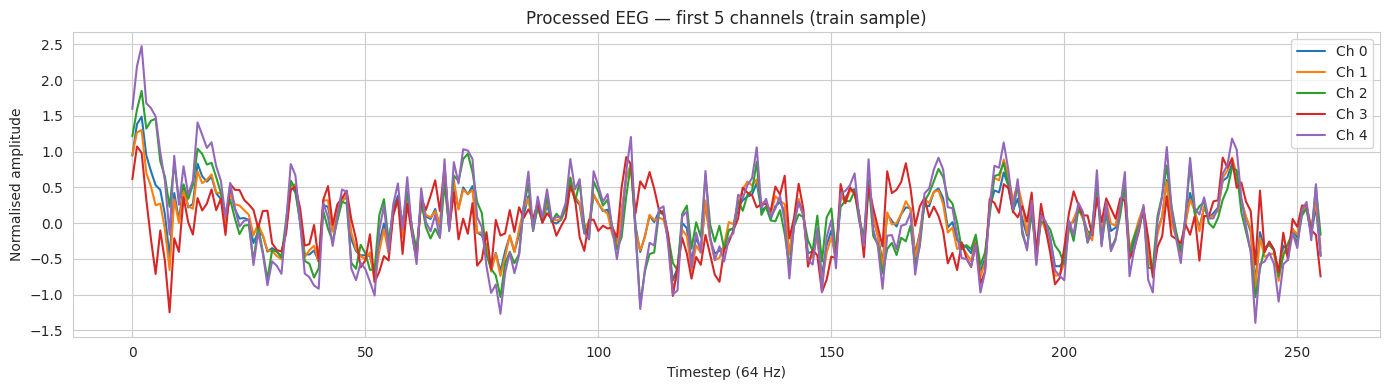

In [12]:
# Optional — plot EEG sample after processing
import matplotlib.pyplot as plt

sample_eeg = train_df["eeg"].iloc[0]   # (256, 24)
plt.figure(figsize=(14, 4))
plt.plot(sample_eeg[:, :5])            # first 5 channels
plt.title("Processed EEG — first 5 channels (train sample)")
plt.xlabel("Timestep (64 Hz)")
plt.ylabel("Normalised amplitude")
plt.legend([f"Ch {i}" for i in range(5)])
plt.tight_layout()
plt.show()

In [13]:
# Optional — plot channel variance
import json
with open("selected_channels.json") as f:
    sel = json.load(f)
print(f"Selected channels: {sel}")

Selected channels: [60, 57, 67, 58, 61, 73, 68, 56, 52, 53, 74, 59, 62, 78, 54, 69, 47, 63, 79, 55, 75, 48, 40, 46]


In [14]:
import mne
import json

# Get standard BioSemi 128 montage
montage = mne.channels.make_standard_montage('biosemi128')
all_channel_names = montage.ch_names
print(f"Total BioSemi128 channels: {len(all_channel_names)}")
print(f"All names: {all_channel_names}")

# Map your indices to names
json_indices = [60, 57, 67, 58, 61, 73, 68, 56, 52, 53, 74, 59, 62, 78, 54, 69, 47, 63, 79, 55, 75, 48, 40, 46]
npy_indices  = [58, 57, 59, 61, 60, 55, 67, 68, 62, 74, 51, 73, 56, 53, 63, 79, 78, 69, 54, 52, 75, 47, 82, 83]

print("\nJSON indices -> channel names:")
for i, idx in enumerate(json_indices):
    print(f"  [{i}] idx={idx} -> {all_channel_names[idx]}")

print("\nNPY indices -> channel names:")
for i, idx in enumerate(npy_indices):
    print(f"  [{i}] idx={idx} -> {all_channel_names[idx]}")

Total BioSemi128 channels: 128
All names: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B31', 'B32', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31', 'D32']

JSON indices -> channel names:
  [0] idx=60 -> B29
  [1] idx=57 -> B26
  [2] idx=67 -> C4
  [3] 

In [15]:
# Check RAM headroom before Cell A
import torch, psutil
print(f"RAM : {psutil.virtual_memory().used/1e9:.1f} GB")
print(f"GPU : {torch.cuda.memory_allocated(0)/1e9:.2f} GB allocated")

# Verify shapes
print(f"\nTrain sample:")
print(f"  eeg shape   : {train_df['eeg'].iloc[0].shape}")
print(f"  conditions  : {train_df['condition'].unique()}")
print(f"  subjects    : {train_df['subject_id'].nunique()}")
print(f"\nVal sample:")
print(f"  conditions  : {val_df['condition'].unique()}")

RAM : 14.0 GB
GPU : 0.00 GB allocated

Train sample:
  eeg shape   : (256, 24)
  conditions  : [0 1 2]
  subjects    : 16

Val sample:
  conditions  : [0 1 2]


In [16]:
import gc
from itertools import combinations

def create_limited_mixed_rows(df, pairs_per_sentence=10):
    mixed_rows = []
    eye_cols  = ['n_fixations','mean_fix_duration','mean_pupilsize']
    spec_mean = ['mean_a1_diff_mean','mean_a2_diff_mean','mean_b1_diff_mean',
                 'mean_b2_diff_mean','mean_g1_diff_mean','mean_g2_diff_mean',
                 'mean_t1_diff_mean','mean_t2_diff_mean']
    spec_arr  = ['mean_a1_diff_array','mean_a2_diff_array','mean_b1_diff_array',
                 'mean_b2_diff_array','mean_g1_diff_array','mean_g2_diff_array',
                 'mean_t1_diff_array','mean_t2_diff_array']

    eye_cols  = [c for c in eye_cols  if c in df.columns]
    spec_mean = [c for c in spec_mean if c in df.columns]
    spec_arr  = [c for c in spec_arr  if c in df.columns]

    for sent_idx, group in df.groupby('sentence_index'):
        if len(group) < 2:
            continue
        rows = list(group.itertuples(index=False))
        all_pairs = list(combinations(rows, 2))
        # Sample up to pairs_per_sentence random pairs
        np.random.seed(int(sent_idx))
        selected = all_pairs if len(all_pairs) <= pairs_per_sentence \
                   else [all_pairs[i] for i in np.random.choice(
                       len(all_pairs), pairs_per_sentence, replace=False)]

        for row_a, row_b in selected:
            new_row = {}
            new_row['sentence_index'] = sent_idx
            new_row['sentence']       = row_a.sentence
            try:
                eeg_a = np.array(row_a.eeg, dtype=np.float32)
                eeg_b = np.array(row_b.eeg, dtype=np.float32)
                if eeg_a.shape != eeg_b.shape: continue
                new_row['eeg'] = (eeg_a + eeg_b) / 2.0
            except: continue
            for col in eye_cols:
                try: new_row[col] = (getattr(row_a,col) + getattr(row_b,col)) / 2.0
                except: new_row[col] = getattr(row_a, col)
            for col in spec_mean:
                try:
                    a = getattr(row_a,col); b = getattr(row_b,col)
                    new_row[col] = ((0 if pd.isna(a) else a) +
                                   (0 if pd.isna(b) else b)) / 2.0
                except: new_row[col] = getattr(row_a, col)
            for col in spec_arr:
                try:
                    a = np.array(getattr(row_a,col)).reshape(-1)
                    b = np.array(getattr(row_b,col)).reshape(-1)
                    new_row[col] = ((a+b)/2.0).reshape(-1,1) if a.shape==b.shape \
                                   else a.reshape(-1,1)
                except: new_row[col] = getattr(row_a, col)
            new_row['condition']  = row_a.condition
            new_row['subject_id'] = f"{row_a.subject_id}+{row_b.subject_id}"
            mixed_rows.append(new_row)

    return pd.DataFrame(mixed_rows)

print("Creating limited mixed rows (3 pairs/sentence)...")
mixed_df = create_limited_mixed_rows(train_df, pairs_per_sentence=3)
print(f"Mixed rows created : {len(mixed_df)}")

train_df_aug = pd.concat([train_df, mixed_df], ignore_index=True).sample(
    frac=1, random_state=42).reset_index(drop=True)
del mixed_df; gc.collect()

print(f"Augmented train    : {len(train_df_aug)}")
print(f"Val unchanged      : {len(val_df)}")
overlap = set(train_df_aug['sentence_index']) & set(val_df['sentence_index'])
print(f"Overlap            : {len(overlap)} {'✅' if len(overlap)==0 else '🚨'}")

import psutil
print(f"RAM: {psutil.virtual_memory().used/1e9:.1f} GB / 16.0 GB")

Creating limited mixed rows (3 pairs/sentence)...
Mixed rows created : 1035
Augmented train    : 11955
Val unchanged      : 2032
Overlap            : 0 ✅
RAM: 14.0 GB / 16.0 GB


In [17]:
import torch, gc, numpy as np, importlib, sys
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from transformers import GPT2Tokenizer, get_cosine_schedule_with_warmup
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
import psutil, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"RAM    : {psutil.virtual_memory().used/1e9:.1f} GB / "
      f"{psutil.virtual_memory().total/1e9:.1f} GB")

Device : cuda
RAM    : 13.9 GB / 16.0 GB


In [18]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.nn.functional as F
 
N_QUBITS = 4   # 4 qubits = 2^4 = 16-dim Hilbert space. Keep ≤4 for speed.
N_LAYERS = 2   # 2 entangling layers. Depth-2 captures meaningful correlations.
 
_qfp_dev = qml.device("lightning.qubit", wires=N_QUBITS)
 
@qml.qnode(_qfp_dev, interface="torch", diff_method="adjoint")
def _eeg_vqc(inputs, weights):
    """
    inputs  : (4,) tensor — compressed EEG embedding, scaled to [-π, π]
    weights : (2, 4, 3) tensor — learnable rotation angles
 
    AngleEmbedding:         RY(input[i]) on qubit i  → data encoding
    StronglyEntanglingLayers: CNOT ladders + Rot gates → entanglement
    Returns 4 Pauli-Z expectations in [-1, 1]  → classical output
    """
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
 
 
class QuantumFusionProjector(nn.Module):
    """
    Residual VQC projector inserted after enc_proj_norm in _encode_eeg.
 
    Trainable parameters:
        down.weight / down.bias : H × 4  (4 × 768 + 4 = 3,076)
        qlayer.weights          : 2 × 4 × 3 = 24  ← quantum params
        up.weight / up.bias     : 4 × H  (4 × 768 + 768 = 3,840)
        norm                    : 2 × H = 1,536
    Total: ~8,476 trainable params  (tiny on top of 124M GPT-2)
    """
 
    def __init__(self, H: int = 768, n_qubits: int = N_QUBITS,
                 n_layers: int = N_LAYERS, dropout: float = 0.1):
        super().__init__()
        self.n_qubits = n_qubits
 
        self.down = nn.Linear(H, n_qubits)
        self.up   = nn.Linear(n_qubits, H)
        self.norm = nn.LayerNorm(H)
        self.drop = nn.Dropout(dropout)
 
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(_eeg_vqc, weight_shapes)
 
        # Near-zero init so VQC starts as approximate identity
        nn.init.normal_(self.down.weight, std=0.01)
        nn.init.zeros_(self.down.bias)
        nn.init.zeros_(self.up.bias)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x       : (B, H)  — fused EEG embedding
        returns : (B, H)  — residual-corrected embedding
        """
        x_small = torch.tanh(self.down(x)) * torch.pi   # (B, 4) in [-π, π]
        q_out   = self.qlayer(x_small)                   # (B, 4) in [-1, 1]
        delta   = self.drop(self.up(q_out))               # (B, H)
        return self.norm(x + delta)
 
 
# ── Sanity check ──────────────────────────────────────────────────
_qfp_chk = QuantumFusionProjector(H=768)
_x_chk   = torch.randn(2, 768)
_o_chk   = _qfp_chk(_x_chk)
assert _o_chk.shape == (2, 768)
_o_chk.sum().backward()
 
n_tr = sum(p.numel() for p in _qfp_chk.parameters() if p.requires_grad)
print(f"✅ QuantumFusionProjector OK — output: {_o_chk.shape} | params: {n_tr:,}")
 
# Print the circuit so you can see what's happening
print("\n── Circuit diagram ─────────────────────────────────────────")
import numpy as np
_dev_vis = qml.device("lightning.qubit", wires=N_QUBITS)
 
@qml.qnode(_dev_vis)
def _vis(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
 
_w0 = np.zeros((N_LAYERS, N_QUBITS, 3))
_i0 = np.zeros(N_QUBITS)
print(qml.draw(_vis)(_i0, _w0))
_sp = qml.specs(_vis)(_i0, _w0)
print(f"\nCircuit depth  : {_sp['resources'].depth}")
print(f"Gate types     : {dict(_sp['resources'].gate_types)}")
del _qfp_chk, _x_chk, _o_chk
 

✅ QuantumFusionProjector OK — output: torch.Size([2, 768]) | params: 8,476

── Circuit diagram ─────────────────────────────────────────
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
[0. 0. 0. 0.]
M1 = 
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]

Circuit depth  : 2
Gate types     : {'AngleEmbedding': 1, 'StronglyEntanglingLayers': 1}


In [19]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

class MultimodalEEGDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64, augment=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.augment   = augment
        self.spec_cols = [
            'mean_a1_diff_mean','mean_a2_diff_mean',
            'mean_b1_diff_mean','mean_b2_diff_mean',
            'mean_g1_diff_mean','mean_g2_diff_mean',
            'mean_t1_diff_mean','mean_t2_diff_mean',
        ]
        self.word_cols = [
            'mean_a1_diff_array','mean_a2_diff_array',
            'mean_b1_diff_array','mean_b2_diff_array',
            'mean_g1_diff_array','mean_g2_diff_array',
            'mean_t1_diff_array','mean_t2_diff_array',
        ]
        self.eye_cols = ['n_fixations','mean_fix_duration','mean_pupilsize']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # EEG with optional noise augmentation
        eeg = torch.tensor(np.array(row['eeg'], dtype=np.float32))
        if self.augment and np.random.random() < 0.5:
            eeg = eeg + torch.randn_like(eeg) * 0.01

        # Spectral (sentence level)
        spec = torch.tensor(row[self.spec_cols].values.astype(np.float32))

        # Word spectral (word level)
        word_arrays = [np.array(row[c]).reshape(-1) for c in self.word_cols]
        sw = np.stack(word_arrays, axis=1)          # (n_words, 8)
        if sw.shape[0] > 50:
            sw = sw[:50]
        else:
            sw = np.vstack([sw, np.zeros((50 - sw.shape[0], 8))])
        spec_words = torch.tensor(sw, dtype=torch.float32)

        # Eye tracking
        eye = torch.tensor(row[self.eye_cols].values.astype(np.float32))

        # Condition
        condition = torch.tensor(int(row['condition']), dtype=torch.long)

        # Tokenise sentence
        encoded = self.tokenizer(
            str(row['sentence']), padding='max_length',
            truncation=True, max_length=self.max_len, return_tensors='pt'
        )

        return {
            "eeg":       eeg,
            "eye":       eye,
            "spec":      spec,
            "spec_words":spec_words,
            "condition": condition,
            "input_ids": encoded["input_ids"].squeeze(0),
        }

BATCH_SIZE = 8

# ── Build datasets ────────────────────────────────────────────────────────────
train_dataset = MultimodalEEGDataset(train_df_aug, tokenizer, augment=True)
val_dataset   = MultimodalEEGDataset(val_df,       tokenizer, augment=False)

# ── Stage 0 loader — real rows only ──────────────────────────────────────────
real_idx = train_df_aug[
    ~train_df_aug['subject_id'].str.contains('\+')
].index.tolist()
np.random.seed(42)
s0_idx = np.random.choice(
    real_idx, size=min(2000, len(real_idx)), replace=False
).tolist()
train_loader_s0 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=SubsetRandomSampler(s0_idx), num_workers=0
)
# Add this right after train_loader_s0 definition
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0
)
print(f"   Full train batches: {len(train_loader)}  (all rows including augmented)")

# ── Val loader ────────────────────────────────────────────────────────────────
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# ── Sanity check ──────────────────────────────────────────────────────────────
b = next(iter(train_loader_s0))
assert b["spec_words"].shape == torch.Size([BATCH_SIZE, 50, 8])
assert b["eeg"].shape        == torch.Size([BATCH_SIZE, 256, 24])
assert b["condition"].max()  <= 2

print(f"✅ Datasets ready")
print(f"   train_df_aug : {len(train_dataset):,} rows  "
      f"({len(real_idx):,} real + {len(train_dataset)-len(real_idx):,} mixed)")
print(f"   val          : {len(val_dataset):,} rows")
print(f"   S0 batches   : {len(train_loader_s0)}  (real only)")
print(f"   conditions   : {b['condition'].unique().tolist()}")
print(f"   eeg shape    : {b['eeg'].shape}")
print(f"   RAM          : {psutil.virtual_memory().used/1e9:.1f} GB")


   Full train batches: 1495  (all rows including augmented)
✅ Datasets ready
   train_df_aug : 11,955 rows  (10,920 real + 1,035 mixed)
   val          : 2,032 rows
   S0 batches   : 250  (real only)
   conditions   : [0, 1, 2]
   eeg shape    : torch.Size([8, 256, 24])
   RAM          : 13.6 GB


In [19]:
import importlib, model1_v9, torch, gc, copy
import numpy as np
from tqdm import tqdm
from transformers import get_cosine_schedule_with_warmup
importlib.reload(model1_v9)
from model1_v9 import (
    EEG2TextTransformerV9, run_epoch,
    MoCoQueue, moco_contrastive_loss, _momentum_update,
)
from torch.utils.data import DataLoader, SubsetRandomSampler
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
train_loader_s0 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=SubsetRandomSampler(s0_idx), num_workers=0
)
print(f"S0 batches: {len(train_loader_s0)}")
 
model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.3,
    contrast_dim=128, region_dim=384,
).to(device)
 
momentum_model = copy.deepcopy(model).to(device)
for p in momentum_model.parameters():
    p.requires_grad = False
 
queue = MoCoQueue(dim=128, queue_size=128, device=device)
 
n_eeg = sum(p.numel() for p in model.eeg_enc.parameters())
print(f"EEGEncoder params (V9 with HTP): {n_eeg:,}")
 
STAGE0_EPOCHS = 30
MAX_PATIENCE0 = 5
 
opt_s0 = torch.optim.AdamW(
    list(model.eeg_enc.parameters()) +
    list(model.contrast_head.parameters()),
    lr=1e-4, weight_decay=0.05,
)
sch_s0 = get_cosine_schedule_with_warmup(
    opt_s0,
    num_warmup_steps   = len(train_loader_s0),
    num_training_steps = STAGE0_EPOCHS * len(train_loader_s0),
)
 
best_s0 = float("inf")
patience = 0
print(f"\n{'='*50}\nSTAGE 0 — MoCo contrastive  ({STAGE0_EPOCHS} epochs)\n{'='*50}")
 
for epoch in range(1, STAGE0_EPOCHS + 1):
    model.train(); total_loss = 0.0
    for batch in tqdm(train_loader_s0, desc=f"S0 ep {epoch}", leave=False):
        loss = moco_contrastive_loss(model, momentum_model, queue, batch, device)
        opt_s0.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_s0.step(); sch_s0.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader_s0)
    print(f"Ep {epoch:02d}  loss={avg:.4f}")
    if avg < best_s0:
        best_s0 = avg; patience = 0
        torch.save(model.state_dict(), "stage0_v9.pt")
        print(f"  ✅ Saved stage0_v9.pt")
    else:
        patience += 1
        if patience >= MAX_PATIENCE0:
            print("  ⏹ Early stop"); break

S0 batches: 250
EEGEncoder params (V9 with HTP): 10,990,860

STAGE 0 — MoCo contrastive  (30 epochs)


Ep 01  loss=4.4956
  ✅ Saved stage0_v9.pt


Ep 02  loss=4.2429
  ✅ Saved stage0_v9.pt


Ep 03  loss=4.1296
  ✅ Saved stage0_v9.pt


Ep 04  loss=4.0795
  ✅ Saved stage0_v9.pt


...

Ep 26  loss=3.8642
  ✅ Saved stage0_v9.pt


Ep 27  loss=3.8570
  ✅ Saved stage0_v9.pt


Ep 28  loss=3.8627


Ep 29  loss=3.8627


Ep 30  loss=3.8615


In [20]:
# del model, opt_s0
gc.collect()
torch.cuda.empty_cache()
print(f"✅ GPU cleared  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
 
importlib.reload(model1_v9)
from model1_v9 import EEG2TextTransformerV9, run_epoch
 
model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.4,
    contrast_dim=128, region_dim=384,
).to(device)
 
ckpt = torch.load("stage0_v9.pt", map_location="cpu")
model.load_state_dict(ckpt); del ckpt
print(f"✅ Loaded stage0_v8.pt  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
 
S1_BATCH = 4
S1_ACCUM = 2
train_loader_s1 = DataLoader(
    train_dataset, batch_size=S1_BATCH, shuffle=True,  num_workers=0)
val_loader_s1   = DataLoader(
    val_dataset,   batch_size=S1_BATCH, shuffle=False, num_workers=0)
print(f"Stage-1 loaders: {len(train_loader_s1)} train / "
      f"{len(val_loader_s1)} val  (batch={S1_BATCH}, accum={S1_ACCUM})")
 
STAGE1_EPOCHS = 20
MAX_PATIENCE  = 3
 
model.stage_1_setup()
model.gpt2.gradient_checkpointing_enable()
print("✅ Gradient checkpointing enabled")
 
opt_s1 = torch.optim.AdamW([
    {"params": model.eeg_enc.parameters(),              "lr": 5e-5},
    {"params": model.eye_enc.parameters(),               "lr": 5e-5},
    {"params": model.spec_enc.parameters(),              "lr": 5e-5},
    {"params": model.spec_word_enc.parameters(),         "lr": 5e-5},
    {"params": model.enc_proj.parameters(),              "lr": 5e-5},
    {"params": model.fusion.parameters(),                "lr": 5e-5},
    {"params": model.contrast_head.parameters(),         "lr": 5e-5},
    {"params": [model.task_prefix],                      "lr": 5e-5},
    {"params": model.condition_emb.parameters(),         "lr": 5e-5},
    {"params": list(model._fusion_norm.parameters()) +
               list(model._enc_proj_norm.parameters()),  "lr": 5e-5},
    {"params": model.sr_adapter.parameters(),            "lr": 2e-5},
], weight_decay=0.05)
 
effective_steps = (len(train_loader_s1) // S1_ACCUM) * STAGE1_EPOCHS
sch_s1 = get_cosine_schedule_with_warmup(
    opt_s1,
    num_warmup_steps   = int(0.05 * effective_steps),
    num_training_steps = effective_steps,
)
 
best_val_s1 = float("inf")
patience    = 0
 
print(f"\n{'='*58}")
print("STAGE 1 — EEG encoder only, GPT-2 fully frozen")
print(f"max={STAGE1_EPOCHS} epochs  patience={MAX_PATIENCE}  accum={S1_ACCUM}")
print(f"{'='*58}")
 
for epoch in range(1, STAGE1_EPOCHS + 1):
 
    # train — checkpointing ON
    model.gpt2.gradient_checkpointing_enable()
    model.train()
    train_loss = 0.0
    opt_s1.zero_grad()
 
    for step, batch in enumerate(tqdm(train_loader_s1,
                                      desc=f"S1 ep{epoch:02d} train",
                                      leave=False)):
        eeg   = batch["eeg"].to(device)
        eye   = batch["eye"].to(device)
        spec  = batch["spec"].to(device)
        specw = batch["spec_words"].to(device)
        cond  = batch["condition"].to(device)
        tgt   = batch["input_ids"].to(device)
 
        logits   = model(eeg, eye, spec, specw, cond, tgt)
        B, T, V  = logits.shape
        loss_tok = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, V),
            tgt[:, 1:].contiguous().reshape(-1),
            ignore_index    = tokenizer.pad_token_id,
            label_smoothing = 0.05,
            reduction       = "none",
        )
        w        = torch.ones(B, device=device)
        w[cond == 2] = 1.5
        tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
        pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                    != tokenizer.pad_token_id).float()
        loss     = (loss_tok * tok_w * pad_mask).sum() / (tok_w * pad_mask).sum()
        (loss / S1_ACCUM).backward()
        train_loss += loss.item()
 
        if (step + 1) % S1_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_s1.step(); sch_s1.step(); opt_s1.zero_grad()
 
    if len(train_loader_s1) % S1_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_s1.step(); sch_s1.step(); opt_s1.zero_grad()
 
    train_loss /= len(train_loader_s1)
 
    # val — checkpointing OFF
    model.gpt2.gradient_checkpointing_disable()
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader_s1,
                          desc=f"S1 ep{epoch:02d} val  ",
                          leave=False):
            eeg   = batch["eeg"].to(device)
            eye   = batch["eye"].to(device)
            spec  = batch["spec"].to(device)
            specw = batch["spec_words"].to(device)
            cond  = batch["condition"].to(device)
            tgt   = batch["input_ids"].to(device)
            logits   = model(eeg, eye, spec, specw, cond, tgt)
            B, T, V  = logits.shape
            loss_tok = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, V),
                tgt[:, 1:].contiguous().reshape(-1),
                ignore_index    = tokenizer.pad_token_id,
                label_smoothing = 0.05,
                reduction       = "none",
            )
            w        = torch.ones(B, device=device)
            w[cond == 2] = 1.5
            tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
            pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                        != tokenizer.pad_token_id).float()
            val_loss += ((loss_tok * tok_w * pad_mask).sum()
                         / (tok_w * pad_mask).sum()).item()
 
    val_loss   /= len(val_loader_s1)
    gap         = train_loss - val_loss
 
    flag = ""
    if val_loss < best_val_s1:
        best_val_s1 = val_loss; patience = 0
        torch.save(model.state_dict(), "stage1_best_v9.pt")
        flag = "  💾"
    else:
        patience += 1
        flag = f"  ({patience}/{MAX_PATIENCE})"
 
    print(f"  Epoch {epoch:02d}/{STAGE1_EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"gap={gap:+.4f}{flag}")
 
    if patience >= MAX_PATIENCE:
        print("  Early stop"); break
 
print(f"\n✅ Stage 1 done  best_val={best_val_s1:.4f} → stage1_best_v9.pt")

✅ GPU cleared  |  VRAM: 1.43 GB
✅ Loaded stage0_v8.pt  |  VRAM: 1.52 GB
Stage-1 loaders: 2989 train / 508 val  (batch=4, accum=2)
[Stage 1] Trainable: 75,411,596 / 147,078,284  (51.3%)
✅ Gradient checkpointing enabled

STAGE 1 — EEG encoder only, GPT-2 fully frozen
max=20 epochs  patience=3  accum=2


S1 ep01 train:   0%|          | 0/2989 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


  Epoch 01/20  train=5.1299  val=4.3239  gap=+0.8060  💾


  Epoch 02/20  train=4.5255  val=4.2697  gap=+0.2558  💾


  Epoch 03/20  train=4.4639  val=4.2541  gap=+0.2099  💾


...

  Epoch 16/20  train=4.3288  val=4.2026  gap=+0.1261  (1/3)


  Epoch 17/20  train=4.3280  val=4.2009  gap=+0.1270  💾


  Epoch 18/20  train=4.3269  val=4.2019  gap=+0.1250  (1/3)


  Epoch 19/20  train=4.3211  val=4.2025  gap=+0.1186  (2/3)


  Epoch 20/20  train=4.3247  val=4.2024  gap=+0.1223  (3/3)
  Early stop

✅ Stage 1 done  best_val=4.2009 → stage1_best_v9.pt


In [21]:
del model, opt_s1, sch_s1

gc.collect()
torch.cuda.empty_cache()

importlib.reload(model1_v9)
from model1_v9 import EEG2TextTransformerV9, run_epoch

model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.4,
    contrast_dim=128, region_dim=384,
).to(device)

ckpt = torch.load("stage1_best_v9.pt", map_location="cpu")
model.load_state_dict(ckpt); del ckpt
print(f"✅ Loaded stage1_best_v9.pt  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Keep batch=4 accum=2 to match Stage 1 gradient landscape
S2_BATCH = 4
S2_ACCUM = 2
train_loader_s2 = DataLoader(
    train_dataset, batch_size=S2_BATCH, shuffle=True,  num_workers=0)
val_loader_s2   = DataLoader(
    val_dataset,   batch_size=S2_BATCH, shuffle=False, num_workers=0)
print(f"Stage-2 loaders: {len(train_loader_s2)} train / "
      f"{len(val_loader_s2)} val  (batch={S2_BATCH}, accum={S2_ACCUM})")

STAGE2_EPOCHS = 20
MAX_PATIENCE2 = 5   # FIX 5: overfitting appears fast, stop early

model.gpt2.gradient_checkpointing_enable()

# FIX 3+4: rank=4, single block [11] only
model.stage_2_setup(lora_rank=4, lora_alpha=8.0, lora_blocks=[11])

# FIX 1+2: near-frozen encoder, very soft LoRA lr
opt_s2 = torch.optim.AdamW([
    # EEG encoder side — near-frozen, tiny lr
    {"params": model.eeg_enc.parameters(),              "lr": 1e-6},
    {"params": model.eye_enc.parameters(),               "lr": 1e-6},
    {"params": model.spec_enc.parameters(),              "lr": 1e-6},
    {"params": model.spec_word_enc.parameters(),         "lr": 1e-6},
    {"params": model.enc_proj.parameters(),              "lr": 1e-6},
    {"params": model.fusion.parameters(),                "lr": 1e-6},
    {"params": [model.task_prefix],                      "lr": 1e-6},
    {"params": model.condition_emb.parameters(),         "lr": 1e-6},
    {"params": list(model._fusion_norm.parameters()) +
               list(model._enc_proj_norm.parameters()),  "lr": 1e-6},
    {"params": model.sr_adapter.parameters(),            "lr": 1e-6},
    # LoRA + lm_head — soft updates
    {"params": [p for n, p in model.gpt2.named_parameters()
                if "lora_A" in n or "lora_B" in n],      "lr": 5e-6},
    {"params": model.gpt2.lm_head.parameters(),          "lr": 2e-6},
], weight_decay=0.05)

effective_steps_s2 = (len(train_loader_s2) // S2_ACCUM) * STAGE2_EPOCHS
sch_s2 = get_cosine_schedule_with_warmup(
    opt_s2,
    num_warmup_steps   = int(0.1 * effective_steps_s2),  # longer warmup
    num_training_steps = effective_steps_s2,
)

best_val_s2 = float("inf")
patience2   = 0

n_lora = sum(p.numel() for n, p in model.gpt2.named_parameters()
             if "lora_A" in n or "lora_B" in n)
print(f"\n  LoRA params: {n_lora:,}  "
      f"(rank=4, block [11] only — {n_lora/345:.0f} params/training sentence)")

print(f"\n{'='*58}")
print("STAGE 2 — LoRA block[11] rank=4, encoder near-frozen")
print(f"max={STAGE2_EPOCHS} epochs  patience={MAX_PATIENCE2}  accum={S2_ACCUM}")
print(f"{'='*58}")

for epoch in range(1, STAGE2_EPOCHS + 1):

    # train — checkpointing ON
    model.gpt2.gradient_checkpointing_enable()
    model.train()
    train_loss = 0.0
    opt_s2.zero_grad()

    for step, batch in enumerate(tqdm(train_loader_s2,
                                      desc=f"S2 ep{epoch:02d} train",
                                      leave=False)):
        eeg   = batch["eeg"].to(device)
        eye   = batch["eye"].to(device)
        spec  = batch["spec"].to(device)
        specw = batch["spec_words"].to(device)
        cond  = batch["condition"].to(device)
        tgt   = batch["input_ids"].to(device)

        logits   = model(eeg, eye, spec, specw, cond, tgt)
        B, T, V  = logits.shape
        loss_tok = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, V),
            tgt[:, 1:].contiguous().reshape(-1),
            ignore_index    = tokenizer.pad_token_id,
            label_smoothing = 0.05,
            reduction       = "none",
        )
        w        = torch.ones(B, device=device)
        w[cond == 2] = 1.5
        tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
        pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                    != tokenizer.pad_token_id).float()
        loss     = (loss_tok * tok_w * pad_mask).sum() / (tok_w * pad_mask).sum()
        (loss / S2_ACCUM).backward()
        train_loss += loss.item()

        if (step + 1) % S2_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_s2.step(); sch_s2.step(); opt_s2.zero_grad()

    if len(train_loader_s2) % S2_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_s2.step(); sch_s2.step(); opt_s2.zero_grad()

    train_loss /= len(train_loader_s2)

    # val — checkpointing OFF
    model.gpt2.gradient_checkpointing_disable()
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader_s2,
                          desc=f"S2 ep{epoch:02d} val  ",
                          leave=False):
            eeg   = batch["eeg"].to(device)
            eye   = batch["eye"].to(device)
            spec  = batch["spec"].to(device)
            specw = batch["spec_words"].to(device)
            cond  = batch["condition"].to(device)
            tgt   = batch["input_ids"].to(device)
            logits   = model(eeg, eye, spec, specw, cond, tgt)
            B, T, V  = logits.shape
            loss_tok = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, V),
                tgt[:, 1:].contiguous().reshape(-1),
                ignore_index    = tokenizer.pad_token_id,
                label_smoothing = 0.05,
                reduction       = "none",
            )
            w        = torch.ones(B, device=device)
            w[cond == 2] = 1.5
            tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
            pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                        != tokenizer.pad_token_id).float()
            val_loss += ((loss_tok * tok_w * pad_mask).sum()
                         / (tok_w * pad_mask).sum()).item()

    val_loss  /= len(val_loader_s2)
    gap        = train_loss - val_loss

    flag = ""
    if val_loss < best_val_s2:
        best_val_s2 = val_loss; patience2 = 0
        torch.save(model.state_dict(), "final_best_v9.pt")
        flag = "  💾"
    else:
        patience2 += 1
        flag = f"  ({patience2}/{MAX_PATIENCE2})"

    print(f"  Epoch {epoch:02d}/{STAGE2_EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"gap={gap:+.4f}{flag}")

    if patience2 >= MAX_PATIENCE2:
        print("  Early stop"); break

# ── Automatic fallback ─────────────────────────────────────────
# If Stage 2 didn't beat Stage 1, use Stage 1 checkpoint
USE_STAGE2 = best_val_s2 < best_val_s1
best_ckpt  = "final_best_v9.pt" if USE_STAGE2 else "stage1_best_v9.pt"

print(f"\n  Stage 1 best val : {best_val_s1:.4f}")
print(f"  Stage 2 best val : {best_val_s2:.4f}")
print(f"  Using checkpoint : {best_ckpt}  "
      f"({'S2 improved' if USE_STAGE2 else '⚠ S2 did not improve — using S1'})")

# Reload whichever is better
ckpt = torch.load(best_ckpt, map_location="cpu")
model.load_state_dict(ckpt, strict=False); del ckpt
model.gpt2.gradient_checkpointing_disable()
model.eval()
print(f"✅ Best model loaded  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

✅ Loaded stage1_best_v9.pt  |  VRAM: 2.32 GB
Stage-2 loaders: 2989 train / 508 val  (batch=4, accum=2)
[Stage 2] LoRA → blocks [11], rank=4
[Stage 2] Trainable: 22,656,908 / 147,096,716  (15.4%)

  LoRA params: 18,432  (rank=4, block [11] only — 53 params/training sentence)

STAGE 2 — LoRA block[11] rank=4, encoder near-frozen
max=20 epochs  patience=5  accum=2


  Epoch 01/20  train=4.3241  val=4.2013  gap=+0.1228  💾


  Epoch 02/20  train=4.3244  val=4.1997  gap=+0.1247  💾


  Epoch 03/20  train=4.3198  val=4.1954  gap=+0.1245  💾


  Epoch 04/20  train=4.3150  val=4.1912  gap=+0.1238  💾


...

  Epoch 16/20  train=4.2879  val=4.1746  gap=+0.1132  💾


  Epoch 17/20  train=4.2838  val=4.1744  gap=+0.1094  💾


  Epoch 18/20  train=4.2897  val=4.1744  gap=+0.1153  💾


  Epoch 19/20  train=4.2836  val=4.1744  gap=+0.1092  💾


  Epoch 20/20  train=4.2893  val=4.1744  gap=+0.1149  💾

  Stage 1 best val : 4.2009
  Stage 2 best val : 4.1744
  Using checkpoint : final_best_v9.pt  (S2 improved)
✅ Best model loaded  |  VRAM: 1.68 GB


In [20]:
import os
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import importlib, model1_v9, torch, gc
import numpy as np
from tqdm import tqdm
 
gc.collect(); torch.cuda.empty_cache()
 
importlib.reload(model1_v9)
from model1_v9 import EEG2TextTransformerV9, alpha_sweep, evaluate_bleu_rouge
 
model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.3,
    contrast_dim=128, region_dim=384,
).to(device)
 
# 3-step load order — identical logic, new checkpoint names
ckpt = torch.load("stage1_best_v9.pt", map_location="cpu")
model.load_state_dict(ckpt); del ckpt
print("✅ Step 1: Stage 1 weights loaded")
 
model.stage_2_setup(lora_rank=4, lora_alpha=16.0, lora_blocks=[11])
print("✅ Step 2: LoRA applied")
 
ckpt = torch.load("final_best_v9.pt", map_location="cpu")
model.load_state_dict(ckpt, strict=False); del ckpt
print("✅ Step 3: final_best_v9.pt loaded")
 
model.gpt2.gradient_checkpointing_disable()
for p in model.parameters(): p.requires_grad = False
model.eval()
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
 
print("\n▶ Alpha sweep")
alpha_sweep(model, val_loader, tokenizer, device, n_batches=20)

✅ Step 1: Stage 1 weights loaded
[Stage 2] LoRA → blocks [11], rank=4
[Stage 2] Trainable: 22,656,908 / 147,096,716  (15.4%)
✅ Step 2: LoRA applied
✅ Step 3: final_best_v9.pt loaded
VRAM: 0.61 GB

▶ Alpha sweep
 alpha   FG BLEU-1
--------------------
   0.0       11.88%
   0.5       11.85%
   1.0       11.97%
   2.0       12.04%
   3.0       12.24%
   4.0       12.36%


In [20]:
BEST_ALPHA = 4.0

smoother = SmoothingFunction().method1
rscorer  = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
tf_b1, tf_b4, r1_list, rl_list = [], [], [], []
eos = tokenizer.eos_token_id
 
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="TF eval"):
        eeg   = batch["eeg"].to(device)
        eye   = batch["eye"].to(device)
        spec  = batch["spec"].to(device)
        specw = batch["spec_words"].to(device)
        cond  = batch["condition"].to(device)
        tgt   = batch["input_ids"].to(device)
 
        logits = model(eeg, eye, spec, specw, cond, tgt)
        preds  = logits[:, :-1, :].argmax(dim=-1)
 
        for j in range(tgt.size(0)):
            ref_ids = tgt[j].tolist()
            if eos in ref_ids: ref_ids = ref_ids[:ref_ids.index(eos)]
            hyp_ids = preds[j].tolist()[:len(ref_ids)]
            r = tokenizer.decode(ref_ids, skip_special_tokens=True)
            h = tokenizer.decode(hyp_ids, skip_special_tokens=True)
            rt, ht = r.lower().split(), h.lower().split()
            if not rt or not ht: continue
            tf_b1.append(sentence_bleu([rt], ht, weights=(1,0,0,0), smoothing_function=smoother))
            tf_b4.append(sentence_bleu([rt], ht, weights=(.25,.25,.25,.25), smoothing_function=smoother))
            sc = rscorer.score(r, h)
            r1_list.append(sc["rouge1"].fmeasure)
            rl_list.append(sc["rougeL"].fmeasure)
 
n = len(tf_b1)
print(f"\n{'='*55}")
print(f"V9 (HTP) — Teacher-Forcing Metrics  (n={n})")
print(f"{'='*55}")
print(f"  TF BLEU-1  : {sum(tf_b1)/n*100:.2f}%   (V8 baseline: 30.40%)")
print(f"  TF BLEU-4  : {sum(tf_b4)/n*100:.2f}%   (V8 baseline:  4.30%)")
print(f"  ROUGE-1    : {sum(r1_list)/n*100:.2f}%   (V8 baseline: 35.78%)")
print(f"  ROUGE-L    : {sum(rl_list)/n*100:.2f}%   (V8 baseline: 30.68%)")

TF eval: 100%|██████████| 254/254 [00:29<00:00,  8.57it/s]


V9 (HTP) — Teacher-Forcing Metrics  (n=2032)
  TF BLEU-1  : 30.71%   (V8 baseline: 30.40%)
  TF BLEU-4  : 4.30%   (V8 baseline:  4.30%)
  ROUGE-1    : 35.96%   (V8 baseline: 35.78%)
  ROUGE-L    : 30.56%   (V8 baseline: 30.68%)


In [21]:
import gc, types, torch, torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
import importlib, model1_v9
importlib.reload(model1_v9)
from model1_v9 import EEG2TextTransformerV9

# FIX 3: free classical model before building hybrid
# del model
gc.collect(); torch.cuda.empty_cache()
print(f"✅ Classical model freed  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

QML_EPOCHS   = 10
QML_LR_QFP   = 3e-4   # VQC params need high LR
QML_LR_REST  = 1e-6   # FIX 6: encoder near-frozen, matches Stage 2
MAX_PATIENCE = 3

# FIX 5: batch=4 loaders to match Stage 1/2 landscape and reduce VRAM
QML_BATCH = 4
QML_ACCUM = 2
qml_train_loader = DataLoader(
    train_dataset, batch_size=QML_BATCH, shuffle=True,  num_workers=0)
qml_val_loader   = DataLoader(
    val_dataset,   batch_size=QML_BATCH, shuffle=False, num_workers=0)
print(f"QML loaders: {len(qml_train_loader)} train / {len(qml_val_loader)} val "
      f"(batch={QML_BATCH}, accum={QML_ACCUM})")

# ── Build hybrid model ─────────────────────────────────────────
hybrid_model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.4,  # FIX 1
    contrast_dim=128, region_dim=384,
).to(device)

_ckpt_s1 = torch.load("stage1_best_v9.pt", map_location="cpu")
hybrid_model.load_state_dict(_ckpt_s1, strict=False); del _ckpt_s1

# FIX 2: rank=4 [11] to match what Stage 2 saved
hybrid_model.stage_2_setup(lora_rank=4, lora_alpha=8.0, lora_blocks=[11])

_ckpt_final = torch.load("final_best_v9.pt", map_location="cpu")
hybrid_model.load_state_dict(_ckpt_final, strict=False); del _ckpt_final

print(f"✅ Loaded final_best_v9.pt  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Graft QuantumFusionProjector ───────────────────────────────
hybrid_model.qfp = QuantumFusionProjector(
    H=768, n_qubits=N_QUBITS, n_layers=N_LAYERS
).to(device)

def _encode_eeg_hybrid(self, eeg, condition=None):
    B = eeg.size(0)
    region_tokens, region_attn_w = self.eeg_enc(eeg)
    query    = self._fusion_query.expand(B, -1, -1)
    fused, _ = self.fusion(query, region_tokens, region_tokens)
    fused    = self._fusion_norm(fused + query)
    fused_sq = fused.squeeze(1)
    out      = self._enc_proj_norm(fused_sq + self.enc_proj(fused_sq))
    if condition is not None:
        out  = self.sr_adapter(out, condition)
    out = self.qfp(out)   # quantum residual
    self._last_region_attn_w = region_attn_w
    return out.unsqueeze(1)

hybrid_model._encode_eeg = types.MethodType(_encode_eeg_hybrid, hybrid_model)
print("✅ QFP grafted into _encode_eeg")

# ── Freeze / unfreeze ──────────────────────────────────────────
for p in hybrid_model.parameters():
    p.requires_grad = False
for p in hybrid_model.qfp.parameters():
    p.requires_grad = True
for name, p in hybrid_model.gpt2.named_parameters():
    if "lora_A" in name or "lora_B" in name or "lm_head" in name:
        p.requires_grad = True
for p in hybrid_model.sr_adapter.parameters():
    p.requires_grad = True

n_tr = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
n_tt = sum(p.numel() for p in hybrid_model.parameters())
print(f"   Trainable: {n_tr:,} / {n_tt:,}  ({100*n_tr/n_tt:.2f}%)")

# ── Optimizer ──────────────────────────────────────────────────
_qfp_params  = list(hybrid_model.qfp.parameters())
_rest_params = [p for p in hybrid_model.parameters()
                if p.requires_grad and not any(p is q for q in _qfp_params)]

optimizer = torch.optim.AdamW([
    {"params": _qfp_params,  "lr": QML_LR_QFP},
    {"params": _rest_params, "lr": QML_LR_REST},
], weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=QML_EPOCHS, eta_min=1e-7)

# ── Fine-tune loop ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"HYBRID QML FINE-TUNE  ({QML_EPOCHS} epochs, patience={MAX_PATIENCE})")
print(f"{'='*55}")

best_val_loss = float("inf")
patience      = 0
qml_history   = {"train": [], "val": []}

for epoch in range(1, QML_EPOCHS + 1):

    # FIX 4: checkpointing ON during train
    hybrid_model.gpt2.gradient_checkpointing_enable()
    hybrid_model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(qml_train_loader,
                                      desc=f"Ep {epoch} train", leave=False)):
        eeg   = batch["eeg"].to(device)
        eye   = batch["eye"].to(device)
        spec  = batch["spec"].to(device)
        specw = batch["spec_words"].to(device)
        cond  = batch["condition"].to(device)
        tgt   = batch["input_ids"].to(device)

        logits   = hybrid_model(eeg, eye, spec, specw, cond, tgt)
        B, T, V  = logits.shape
        loss_tok = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, V),
            tgt[:, 1:].contiguous().reshape(-1),
            ignore_index    = tokenizer.pad_token_id,
            label_smoothing = 0.05,
            reduction       = "none",
        )
        w        = torch.ones(B, device=device)
        w[cond == 2] = 1.5
        tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
        pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                    != tokenizer.pad_token_id).float()
        loss     = (loss_tok * tok_w * pad_mask).sum() / (tok_w * pad_mask).sum()
        (loss / QML_ACCUM).backward()
        train_loss += loss.item()

        if (step + 1) % QML_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), 1.0)
            optimizer.step(); optimizer.zero_grad()

    if len(qml_train_loader) % QML_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()

    train_loss /= len(qml_train_loader)
    scheduler.step()

    # FIX 4: checkpointing OFF during val
    hybrid_model.gpt2.gradient_checkpointing_disable()
    hybrid_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(qml_val_loader,
                          desc=f"Ep {epoch} val  ", leave=False):
            eeg   = batch["eeg"].to(device)
            eye   = batch["eye"].to(device)
            spec  = batch["spec"].to(device)
            specw = batch["spec_words"].to(device)
            cond  = batch["condition"].to(device)
            tgt   = batch["input_ids"].to(device)
            logits   = hybrid_model(eeg, eye, spec, specw, cond, tgt)
            B, T, V  = logits.shape
            loss_tok = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, V),
                tgt[:, 1:].contiguous().reshape(-1),
                ignore_index    = tokenizer.pad_token_id,
                label_smoothing = 0.05,
                reduction       = "none",
            )
            w        = torch.ones(B, device=device)
            w[cond == 2] = 1.5
            tok_w    = w.unsqueeze(1).expand(B, T-1).contiguous().reshape(-1)
            pad_mask = (tgt[:, 1:].contiguous().reshape(-1)
                        != tokenizer.pad_token_id).float()
            val_loss += ((loss_tok * tok_w * pad_mask).sum()
                         / (tok_w * pad_mask).sum()).item()

    val_loss /= len(qml_val_loader)
    qml_history["train"].append(train_loss)
    qml_history["val"].append(val_loss)
    print(f"Ep {epoch:02d}  train={train_loss:.4f}  val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience = 0
        torch.save(hybrid_model.state_dict(), "hybrid_qml_v9_best.pt")
        print(f"        ✅ Saved hybrid_qml_v9_best.pt")
    else:
        patience += 1
        if patience >= MAX_PATIENCE:
            print(f"        ⏹  Early stop"); break

# Reload best hybrid weights
_ckpt_hybrid = torch.load("hybrid_qml_v9_best.pt", map_location="cpu")
hybrid_model.load_state_dict(_ckpt_hybrid, strict=False); del _ckpt_hybrid
hybrid_model.gpt2.gradient_checkpointing_disable()
hybrid_model.eval()
print(f"\n✅ Best hybrid loaded  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── FIX 7: reload classical model for head-to-head ────────────
# Now QML training is done, reload classical — eval one at a time
importlib.reload(model1_v9)
from model1_v9 import EEG2TextTransformerV9

model = EEG2TextTransformerV9(
    gpt_model_name="gpt2", n_heads=4, dropout=0.4,
    contrast_dim=128, region_dim=384,
).to(device)
_ck = torch.load("stage1_best_v9.pt", map_location="cpu")
model.load_state_dict(_ck, strict=False); del _ck
model.stage_2_setup(lora_rank=4, lora_alpha=8.0, lora_blocks=[11])
_ck = torch.load("final_best_v9.pt", map_location="cpu")
model.load_state_dict(_ck, strict=False); del _ck
model.gpt2.gradient_checkpointing_disable()
model.eval()
print(f"✅ Classical model reloaded  |  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Head-to-head eval — one model at a time to save VRAM ──────
_smoother = SmoothingFunction().method1
_rscorer  = rouge_lib.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
_eos      = tokenizer.eos_token_id


def _eval_bleu_rouge(mdl, loader, label):
    mdl.eval()
    b1, b4, r1, rl = [], [], [], []
    cond_b1 = {0: [], 1: [], 2: []}
    with torch.no_grad():
        for batch in tqdm(loader, desc=label, leave=False):
            eeg   = batch["eeg"].to(device)
            eye   = batch["eye"].to(device)
            spec  = batch["spec"].to(device)
            specw = batch["spec_words"].to(device)
            cond  = batch["condition"].to(device)
            tgt   = batch["input_ids"].to(device)
            logits = mdl(eeg, eye, spec, specw, cond, tgt)
            preds  = logits[:, :-1, :].argmax(dim=-1)
            for j in range(tgt.size(0)):
                ref_ids = tgt[j].tolist()
                if _eos in ref_ids: ref_ids = ref_ids[:ref_ids.index(_eos)]
                hyp_ids = preds[j].tolist()[:len(ref_ids)]
                r = tokenizer.decode(ref_ids, skip_special_tokens=True)
                h = tokenizer.decode(hyp_ids, skip_special_tokens=True)
                rt, ht = r.lower().split(), h.lower().split()
                if not rt or not ht: continue
                s1 = sentence_bleu([rt], ht, weights=(1,0,0,0),
                                   smoothing_function=_smoother)
                b1.append(s1)
                cond_b1[cond[j].item()].append(s1)
                b4.append(sentence_bleu([rt], ht, weights=(.25,.25,.25,.25),
                                        smoothing_function=_smoother))
                sc = _rscorer.score(r, h)
                r1.append(sc["rouge1"].fmeasure)
                rl.append(sc["rougeL"].fmeasure)
    n = len(b1)
    return {
        "n":      n,
        "bleu1":  sum(b1)/n*100,
        "bleu4":  sum(b4)/n*100,
        "rouge1": sum(r1)/n*100,
        "rougeL": sum(rl)/n*100,
        "cond":   {c: (sum(s)/len(s)*100 if s else 0.0)
                   for c, s in cond_b1.items()},
    }


# Eval classical, move to CPU, then eval hybrid
res_classical = _eval_bleu_rouge(model, val_loader, "Classical V9")
model.cpu(); gc.collect(); torch.cuda.empty_cache()

res_hybrid = _eval_bleu_rouge(hybrid_model, val_loader, "Hybrid QML")

model.to(device)  # restore for downstream cells

# ── Overall comparison ─────────────────────────────────────────
print(f"\n{'Metric':<12} {'Classical V8':>14} {'Hybrid QML':>12} {'Δ':>8}")
print("─" * 52)
for key, label in [("bleu1","TF BLEU-1"), ("bleu4","TF BLEU-4"),
                   ("rouge1","ROUGE-1"),   ("rougeL","ROUGE-L")]:
    c = res_classical[key]; h = res_hybrid[key]; d = h - c
    print(f"{label:<12} {c:>14.2f}%  {h:>10.2f}%  "
          f"{'+' if d>=0 else ''}{d:>6.2f}%")
print(f"\nSamples : {res_hybrid['n']}")

# ── FIX 8: per-condition using live classical eval ─────────────
_cond_names = {0: "NR", 1: "TSR", 2: "SR"}
print(f"\n{'='*54}")
print("PER-CONDITION BLEU-1")
print(f"{'='*54}")
print(f"{'Condition':<10} {'Classical':>12} {'Hybrid QML':>12} {'Δ':>8}")
print("─" * 48)
for c_id, name in _cond_names.items():
    cl  = res_classical["cond"][c_id]
    hyb = res_hybrid["cond"][c_id]
    d   = hyb - cl
    print(f"  {name:<8}  {cl:>12.2f}%  {hyb:>10.2f}%  "
          f"{'+' if d>=0 else ''}{d:>6.2f}%")

✅ Classical model freed  |  VRAM: 0.74 GB
QML loaders: 2989 train / 508 val (batch=4, accum=2)
[Stage 2] LoRA → blocks [11], rank=4
[Stage 2] Trainable: 22,656,908 / 147,096,716  (15.4%)
✅ Loaded final_best_v9.pt  |  VRAM: 1.35 GB
✅ QFP grafted into _encode_eeg
   Trainable: 5,343,004 / 147,105,192  (3.63%)

HYBRID QML FINE-TUNE  (10 epochs, patience=3)


Ep 1 train:   0%|          | 0/2989 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Ep 01  train=4.2850  val=4.1754
        ✅ Saved hybrid_qml_v9_best.pt


Ep 02  train=4.2857  val=4.1750
        ✅ Saved hybrid_qml_v9_best.pt


Ep 03  train=4.2837  val=4.1741
        ✅ Saved hybrid_qml_v9_best.pt


...

Ep 07  train=4.2855  val=4.1735
        ✅ Saved hybrid_qml_v9_best.pt


Ep 08  train=4.2821  val=4.1737


Ep 09  train=4.2841  val=4.1734
        ✅ Saved hybrid_qml_v9_best.pt


Ep 10  train=4.2839  val=4.1733
        ✅ Saved hybrid_qml_v9_best.pt

✅ Best hybrid loaded  |  VRAM: 1.34 GB
[Stage 2] LoRA → blocks [11], rank=4
[Stage 2] Trainable: 22,656,908 / 147,096,716  (15.4%)
✅ Classical model reloaded  |  VRAM: 1.34 GB



Metric         Classical V8   Hybrid QML        Δ
────────────────────────────────────────────────────
TF BLEU-1             31.02%       31.00%   -0.03%
TF BLEU-4              4.45%        4.47%  +  0.02%
ROUGE-1               36.07%       36.04%   -0.03%
ROUGE-L               30.79%       30.80%  +  0.01%

Samples : 2032

PER-CONDITION BLEU-1
Condition     Classical   Hybrid QML        Δ
────────────────────────────────────────────────
  NR               31.65%       31.55%   -0.10%
  TSR              33.79%       33.89%  +  0.09%
  SR               27.46%       27.37%   -0.09%


In [22]:
import subprocess, sys
try:
    from bert_score import score as bert_score_fn
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bert-score"])
    from bert_score import score as bert_score_fn
 
print("Computing BERTScore on V9 classical and hybrid QML...")
 
def _collect_refs_hyps(mdl, loader):
    mdl.eval()
    refs_all, hyps_all, cond_all = [], [], []
    _eos_bs = tokenizer.eos_token_id
    with torch.no_grad():
        for batch in tqdm(loader, desc="BERTScore collect", leave=False):
            eeg   = batch["eeg"].to(device); eye  = batch["eye"].to(device)
            spec  = batch["spec"].to(device); specw= batch["spec_words"].to(device)
            cond  = batch["condition"].to(device); tgt = batch["input_ids"].to(device)
            logits = mdl(eeg, eye, spec, specw, cond, tgt)
            preds  = logits[:, :-1, :].argmax(dim=-1)
            for j in range(tgt.size(0)):
                ref_ids = tgt[j].tolist()
                if _eos_bs in ref_ids: ref_ids = ref_ids[:ref_ids.index(_eos_bs)]
                hyp_ids = preds[j].tolist()[:len(ref_ids)]
                refs_all.append(tokenizer.decode(ref_ids, skip_special_tokens=True))
                hyps_all.append(tokenizer.decode(hyp_ids, skip_special_tokens=True))
                cond_all.append(cond[j].item())
    return refs_all, hyps_all, cond_all
 
refs_c, hyps_c, conds_c = _collect_refs_hyps(model,        val_loader)
refs_h, hyps_h, conds_h = _collect_refs_hyps(hybrid_model, val_loader)
 
_, _, F1_c = bert_score_fn(hyps_c, refs_c, lang="en", verbose=False)
_, _, F1_h = bert_score_fn(hyps_h, refs_h, lang="en", verbose=False)
 
f1_c = F1_c.mean().item() * 100
f1_h = F1_h.mean().item() * 100
 
print(f"\n{'='*52}")
print("BERTScore F1 comparison")
print(f"{'='*52}")
print(f"  V9 classical  : {f1_c:.2f}%  ")
print(f"  V9 hybrid QML : {f1_h:.2f}%")
print(f"  Δ (hybrid–classical): {f1_h - f1_c:+.2f}%")
 
# Per-condition BERTScore
import numpy as np
cond_names_bs = {0: "NR", 1: "TSR", 2: "SR"}
print(f"\nPer-condition BERTScore F1:")
print(f"{'Condition':<10} {'V9 classical':>14} {'V9 hybrid QML':>14} {'Δ':>8}")
print("─" * 50)
for c_id in [0, 1, 2]:
    mask_c = [i for i, c in enumerate(conds_c) if c == c_id]
    mask_h = [i for i, c in enumerate(conds_h) if c == c_id]
    f1_cond_c = F1_c[mask_c].mean().item() * 100 if mask_c else 0.0
    f1_cond_h = F1_h[mask_h].mean().item() * 100 if mask_h else 0.0
    d = f1_cond_h - f1_cond_c
    print(f"  {cond_names_bs[c_id]:<8}  {f1_cond_c:>14.2f}%  {f1_cond_h:>13.2f}%  "
          f"{'+' if d>=0 else ''}{d:>6.2f}%")

Computing BERTScore on V9 classical and hybrid QML...


BERTScore collect:   0%|          | 0/254 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



BERTScore F1 comparison
  V9 classical  : 85.50%  
  V9 hybrid QML : 85.51%
  Δ (hybrid–classical): +0.01%

Per-condition BERTScore F1:
Condition    V9 classical  V9 hybrid QML        Δ
──────────────────────────────────────────────────
  NR                 85.49%          85.50%  +  0.01%
  TSR                86.42%          86.43%  +  0.01%
  SR                 84.53%          84.54%  +  0.01%


Region                            Mean entropy   Entropy ratio       Verdict
────────────────────────────────────────────────────────────────────────────
  left_temporal                        26.6949          4.8141   ⚠ COLLAPSED
  left_parietal                        17.8657          3.2218   ⚠ COLLAPSED
  left_parieto_occipital               17.1175          3.0869   ⚠ COLLAPSED
  central_parietal                     25.5765          4.6124   ⚠ COLLAPSED
  right_parietal                       23.9529          4.3196   ⚠ COLLAPSED
  right_parieto_occipital              27.5998          4.9773   ⚠ COLLAPSED

  Uniform 1/T entropy : 5.5452  (ratio 1.0 = fully collapsed)

  Per-condition entropy ratios (lower = more selective):
  Region                              NR       TSR        SR
  ────────────────────────────────────────────────────────
  left_temporal                   4.8140    4.8106    4.8180
  left_parietal                   3.2556    3.1416    3.2789
  left_parieto_occipi

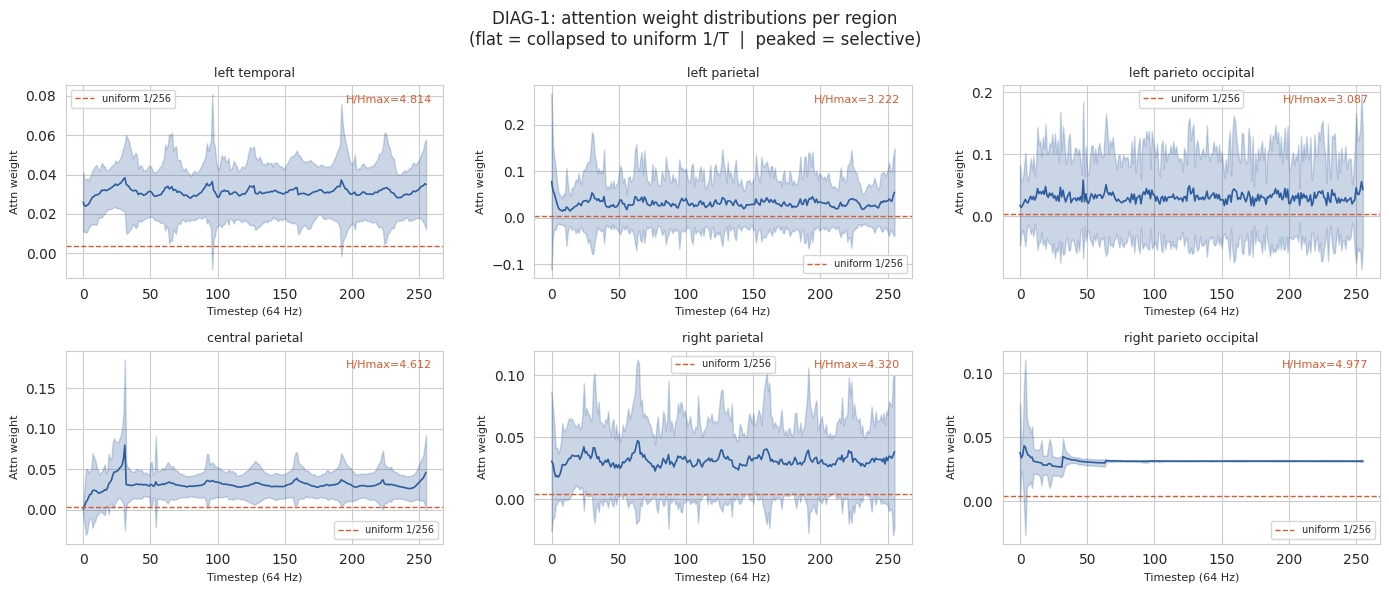


✅ Saved diag1_pool_attn_collapse.png


In [21]:
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model1_v9 import REGION_NAMES

# shuffled loader — all 3 conditions in every batch
diag_loader = DataLoader(val_dataset, batch_size=8, shuffle=True, num_workers=0)

model.eval()
all_weights  = {name: [] for name in REGION_NAMES}
cond_weights = {name: {0: [], 1: [], 2: []} for name in REGION_NAMES}
N_DIAG = 20   # 20 × 8 = 160 samples, all 3 conditions covered

with torch.no_grad():
    for i, batch in enumerate(diag_loader):
        if i >= N_DIAG:
            break
        eeg  = batch["eeg"].to(device)
        eye  = batch["eye"].to(device)
        spec = batch["spec"].to(device)
        specw= batch["spec_words"].to(device)
        cond = batch["condition"].to(device)
        tgt  = batch["input_ids"].to(device)

        _ = model(eeg, eye, spec, specw, cond, tgt)

        for name, attn in zip(REGION_NAMES, model._last_region_attn_w):
            # Handle both V8 (plain tensor) and V9/HTP (tuple) returns
            if isinstance(attn, tuple):
                w = attn[0]   # local_w: (B, T, 1)
            else:
                w = attn      # plain tensor: (B, T, 1)

            w_np = w.squeeze(-1).cpu().numpy()   # (B, T)
            all_weights[name].append(w_np)
            for b_idx in range(w_np.shape[0]):
                c_id = cond[b_idx].item()
                cond_weights[name][c_id].append(w_np[b_idx])

# ── Overall entropy per region ─────────────────────────────────
T           = next(iter(all_weights.values()))[0].shape[1]
max_entropy = np.log(T)

print(f"{'Region':<30}  {'Mean entropy':>14}  {'Entropy ratio':>14}  {'Verdict':>12}")
print("─" * 76)

region_entropies = {}
for name in REGION_NAMES:
    w_all  = np.concatenate(all_weights[name], axis=0)
    w_clip = np.clip(w_all, 1e-9, 1.0)
    entropy = -(w_clip * np.log(w_clip)).sum(axis=1).mean()
    ratio   = entropy / max_entropy
    region_entropies[name] = ratio
    verdict = ("⚠ COLLAPSED" if ratio > 0.95
               else ("selective" if ratio < 0.80 else "marginal"))
    print(f"  {name:<28}  {entropy:>14.4f}  {ratio:>14.4f}  {verdict:>12}")

print(f"\n  Uniform 1/T entropy : {max_entropy:.4f}  (ratio 1.0 = fully collapsed)")

# ── Per-condition entropy breakdown ────────────────────────────
cond_names_d1 = {0: "NR", 1: "TSR", 2: "SR"}
print(f"\n  Per-condition entropy ratios (lower = more selective):")
print(f"  {'Region':<28}  {'NR':>8}  {'TSR':>8}  {'SR':>8}")
print(f"  {'─'*56}")
for name in REGION_NAMES:
    row = []
    for c_id in [0, 1, 2]:
        samples = cond_weights[name][c_id]
        if samples:
            w_c = np.stack(samples)
            w_c = np.clip(w_c, 1e-9, 1.0)
            ent = -(w_c * np.log(w_c)).sum(axis=1).mean() / max_entropy
        else:
            ent = 0.0
        row.append(ent)
    print(f"  {name:<28}  {row[0]:>8.4f}  {row[1]:>8.4f}  {row[2]:>8.4f}")

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("DIAG-1: attention weight distributions per region\n"
             "(flat = collapsed to uniform 1/T  |  peaked = selective)",
             fontsize=12)

for ax, name in zip(axes.flatten(), REGION_NAMES):
    w_all  = np.concatenate(all_weights[name], axis=0)
    w_mean = w_all.mean(axis=0)
    w_std  = w_all.std(axis=0)
    t      = np.arange(T)
    ax.plot(t, w_mean, color="#2E5D9E", linewidth=1.2)
    ax.fill_between(t, w_mean - w_std, w_mean + w_std,
                    alpha=0.25, color="#2E5D9E")
    ax.axhline(1/T, color="#D85A30", linewidth=1,
               linestyle="--", label=f"uniform 1/{T}")
    ax.set_title(name.replace("_", " "), fontsize=9)
    ax.set_xlabel("Timestep (64 Hz)", fontsize=8)
    ax.set_ylabel("Attn weight", fontsize=8)
    ax.legend(fontsize=7)
    ratio = region_entropies[name]
    ax.text(0.97, 0.95, f"H/Hmax={ratio:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            color="#D85A30" if ratio > 0.95 else "#2E5D9E")

plt.tight_layout()
plt.savefig("diag1_pool_attn_collapse.png", dpi=150)
plt.show()
print("\n✅ Saved diag1_pool_attn_collapse.png")


Region                                NR       TSR        SR
────────────────────────────────────────────────────────────
  left_temporal                   0.1378    0.1427    0.1396
  left_parietal                   0.1827    0.1800    0.1804
  left_parieto_occipital          0.2183    0.2163    0.2185
  central_parietal                0.1382    0.1416    0.1406
  right_parietal                  0.1810    0.1750    0.1778
  right_parieto_occipital         0.1420    0.1444    0.1432

  Dominant region: left_parieto_occipital


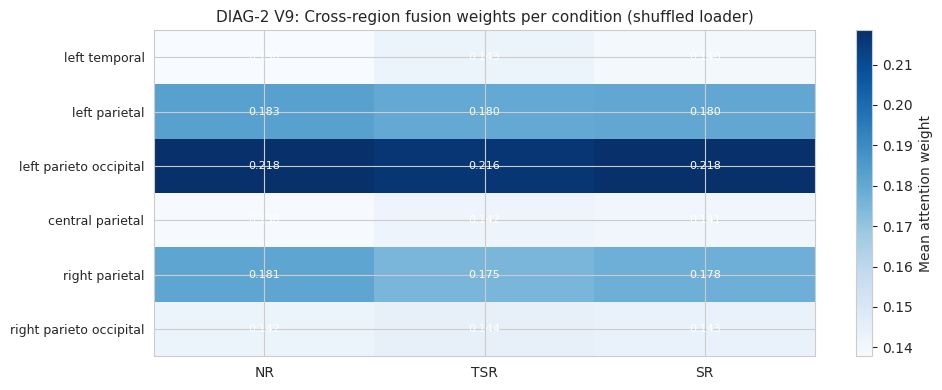

✅ Saved diag2_v9_fusion_weights.png

Selectivity std across regions per condition:
  NR: std=0.0299  dominant=left parieto occipital
  TSR: std=0.0271  dominant=left parieto occipital
  SR: std=0.0288  dominant=left parieto occipital
  (std > 0.05 = meaningful, std ≈ 0 = collapsed to 1/6)


In [ ]:
import torch, types, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model1_v9 import REGION_NAMES
 
# FIX: shuffled loader so all 3 conditions appear in every batch
diag_loader = DataLoader(val_dataset, batch_size=8, shuffle=True, num_workers=0)
 
_saved_fw = []
 
def _encode_eeg_capture_d2(self, eeg, condition=None):
    B = eeg.size(0)
    region_tokens, region_attn_w = self.eeg_enc(eeg)
    query = self._fusion_query.expand(B, -1, -1)
    fused, fusion_w = self.fusion(
        query, region_tokens, region_tokens,
        average_attn_weights=True, need_weights=True)
    _saved_fw.append(fusion_w.detach().cpu())
    fused    = self._fusion_norm(fused + query)
    fused_sq = fused.squeeze(1)
    out      = self._enc_proj_norm(fused_sq + self.enc_proj(fused_sq))
    if condition is not None: out = self.sr_adapter(out, condition)
    self._last_region_attn_w = region_attn_w
    return out.unsqueeze(1)
 
_orig_enc_d2      = model._encode_eeg.__func__
model._encode_eeg = types.MethodType(_encode_eeg_capture_d2, model)
 
model.eval()
cond_fusion_weights = {0: [], 1: [], 2: []}
 
with torch.no_grad():
    for i, batch in enumerate(diag_loader):
        if i >= 15: break    # 15 batches × 8 = 120 samples, all 3 conditions covered
        eeg  = batch["eeg"].to(device); eye  = batch["eye"].to(device)
        spec = batch["spec"].to(device); specw= batch["spec_words"].to(device)
        cond = batch["condition"].to(device); tgt = batch["input_ids"].to(device)
        _ = model(eeg, eye, spec, specw, cond, tgt)
        fw = _saved_fw[-1]
        for b_idx in range(fw.size(0)):
            c = cond[b_idx].item()
            cond_fusion_weights[c].append(fw[b_idx, 0, :].numpy())
 
model._encode_eeg = types.MethodType(_orig_enc_d2, model)
_saved_fw.clear()
 
cond_names_d2 = {0: "NR", 1: "TSR", 2: "SR"}
mean_weights = {}
print(f"\n{'Region':<30}", end="")
for c_id in [0,1,2]: print(f"  {cond_names_d2[c_id]:>8}", end="")
print(); print("─" * 60)
for r_idx, rname in enumerate(REGION_NAMES):
    print(f"  {rname:<28}", end="")
    mean_weights[rname] = {}
    for c_id in [0,1,2]:
        arr = np.array(cond_fusion_weights[c_id])
        m   = arr[:, r_idx].mean() if len(arr) else 0.0
        mean_weights[rname][c_id] = m
        print(f"  {m:>8.4f}", end="")
    print()
 
dominant = max(REGION_NAMES, key=lambda n: np.mean([mean_weights[n][c] for c in [0,1,2]]))
print(f"\n  Dominant region: {dominant}")
 
fig, ax = plt.subplots(figsize=(10, 4))
mat = np.array([[mean_weights[r][c] for c in [0,1,2]] for r in REGION_NAMES])
im  = ax.imshow(mat, aspect="auto", cmap="Blues")
ax.set_xticks([0,1,2]); ax.set_xticklabels(["NR","TSR","SR"])
ax.set_yticks(range(6)); ax.set_yticklabels([r.replace("_"," ") for r in REGION_NAMES], fontsize=9)
ax.set_title("DIAG-2 V9: Cross-region fusion weights per condition (shuffled loader)", fontsize=11)
plt.colorbar(im, ax=ax, label="Mean attention weight")
for i in range(6):
    for j in range(3):
        ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=8,
                color="white" if mat[i,j] > mat.max()*0.6 else "black")
plt.tight_layout()
plt.savefig("diag2_v9_fusion_weights.png", dpi=150); plt.show()
print("✅ Saved diag2_v9_fusion_weights.png")
 
print(f"\nSelectivity std across regions per condition:")
for c_id in [0,1,2]:
    row = mat[:, c_id]
    print(f"  {cond_names_d2[c_id]}: std={row.std():.4f}  "
          f"dominant={REGION_NAMES[row.argmax()].replace('_',' ')}")
print("  (std > 0.05 = meaningful, std ≈ 0 = collapsed to 1/6)")

In [ ]:
import torch
import types
import numpy as np
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
 
diag_loader = DataLoader(val_dataset, batch_size=8, shuffle=True, num_workers=0)
 
_smoother3 = SmoothingFunction().method1
_eos3      = tokenizer.eos_token_id
 
 
def _encode_eeg_no_adapter(self, eeg, condition=None):
    """_encode_eeg with sr_adapter bypassed — identical otherwise."""
    B = eeg.size(0)
    region_tokens, region_attn_w = self.eeg_enc(eeg)
    query    = self._fusion_query.expand(B, -1, -1)
    fused, _ = self.fusion(query, region_tokens, region_tokens)
    fused    = self._fusion_norm(fused + query)
    fused_sq = fused.squeeze(1)
    out      = self._enc_proj_norm(fused_sq + self.enc_proj(fused_sq))
    # sr_adapter BYPASSED
    self._last_region_attn_w = region_attn_w
    return out.unsqueeze(1)
 
 
def _eval_tf_bleu_cond(mdl, loader, n_batches=30):
    """Teacher-forcing BLEU-1 per condition."""
    mdl.eval()
    cond_scores = {0: [], 1: [], 2: []}
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            eeg  = batch["eeg"].to(device)
            eye  = batch["eye"].to(device)
            spec = batch["spec"].to(device)
            specw= batch["spec_words"].to(device)
            cond = batch["condition"].to(device)
            tgt  = batch["input_ids"].to(device)
            logits = mdl(eeg, eye, spec, specw, cond, tgt)
            preds  = logits[:, :-1, :].argmax(dim=-1)
            for j in range(tgt.size(0)):
                c_id    = cond[j].item()
                ref_ids = tgt[j].tolist()
                if _eos3 in ref_ids:
                    ref_ids = ref_ids[:ref_ids.index(_eos3)]
                hyp_ids = preds[j].tolist()[:len(ref_ids)]
                r  = tokenizer.decode(ref_ids, skip_special_tokens=True)
                h  = tokenizer.decode(hyp_ids, skip_special_tokens=True)
                rt, ht = r.lower().split(), h.lower().split()
                if rt and ht:
                    cond_scores[c_id].append(
                        sentence_bleu([rt], ht, weights=(1,0,0,0),
                                      smoothing_function=_smoother3))
    counts = {c: len(s) for c, s in cond_scores.items()}
    print(f"  Samples — NR:{counts[0]}  TSR:{counts[1]}  SR:{counts[2]}")
    return {c: (sum(s)/len(s)*100 if s else 0.0) for c, s in cond_scores.items()}
 
 
N_ABL = 30
 
print("Running with adapter...")
scores_with    = _eval_tf_bleu_cond(model, diag_loader, n_batches=N_ABL)
 
print("Running without adapter...")
_orig_enc         = model._encode_eeg.__func__
model._encode_eeg = types.MethodType(_encode_eeg_no_adapter, model)
scores_without    = _eval_tf_bleu_cond(model, diag_loader, n_batches=N_ABL)
model._encode_eeg = types.MethodType(_orig_enc, model)   # restore
 
cond_names3 = {0: "NR", 1: "TSR", 2: "SR"}
print(f"\n{'='*54}")
print("DIAG-3: SR adapter ablation (TF BLEU-1 %)")
print(f"{'='*54}")
print(f"{'Condition':<12}  {'With adapter':>14}  {'Without':>10}  {'Δ':>8}")
print("─" * 50)
for c_id in [0, 1, 2]:
    w  = scores_with[c_id]
    wo = scores_without[c_id]
    d  = w - wo
    print(f"  {cond_names3[c_id]:<10}  {w:>14.2f}%  {wo:>10.2f}%  "
          f"{'+' if d>=0 else ''}{d:>6.2f}%")
print()
print("Interpretation:")
print("  Δ > +1% on SR   → adapter contributing for fast reading")
print("  Δ ≈ 0 on NR/TSR → adapter not hurting stable conditions")
print("  Δ < -2% on TSR  → adapter overfit to NR/SR; reduce adapter LR")


DIAG-3 V9: SR adapter ablation (TF BLEU-1 %)
Condition       With adapter     Without         Δ
──────────────────────────────────────────────────
  NR                   32.48%       30.09%  +  2.40%
  TSR                  31.30%       35.82%   -4.52%
  SR                   28.54%       25.49%  +  3.05%

  Δ > +1% on SR  → adapter contributing for fast reading
  Δ ≈ 0 on NR/TSR → adapter not hurting stable conditions
  Δ < 0           → adapter hurting — reduce adapter dropout


In [ ]:
import torch.nn as nn
 
def count_params(module):
    return sum(p.numel() for p in module.parameters())
 
components = {
    "EEGEncoder (6×RegionEncoderV9)": model.eeg_enc,
    "EyeEncoder":                     model.eye_enc,
    "SpectralEncoder":                model.spec_enc,
    "WordSpectralEncoder":            model.spec_word_enc,
    "Fusion MHA + norm":              nn.ModuleList([model.fusion, model._fusion_norm]),
    "enc_proj + norm":                nn.ModuleList([model.enc_proj, model._enc_proj_norm]),
    "SRConditionAdapter":             model.sr_adapter,
    "ContrastHead (MoCo)":            model.contrast_head,
    "GPT-2 base (frozen)":           model.gpt2,
}
 
total = count_params(model)
print(f"\n{'='*65}")
print(f"DIAG-4: V9 Component Complexity")
print(f"{'='*65}")
print(f"{'Component':<35}  {'Params':>10}  {'% total':>9}")
print("─" * 58)
for name, mod in components.items():
    if isinstance(mod, nn.ModuleList):
        p_all = sum(count_params(m) for m in mod)
    else:
        p_all = count_params(mod)
    pct = 100 * p_all / total
    print(f"  {name:<33}  {p_all:>10,}  {pct:>9.2f}%")
 
p_lora = sum(p.numel() for n, p in model.gpt2.named_parameters()
             if "lora_A" in n or "lora_B" in n)
print(f"  {'  └─ LoRA adapters (rank=8)':<33}  {p_lora:>10,}  "
      f"{100*p_lora/total:>9.4f}%")
print("─" * 58)
print(f"  {'TOTAL':<33}  {total:>10,}")
 
print(f"\n  V8 vs V9 EEGEncoder delta:")
v8_eeg_params = 10_096_902   # from your DIAG-4 output
v9_eeg_params = count_params(model.eeg_enc)
print(f"  V8 EEGEncoder: {v8_eeg_params:,}  →  V9 EEGEncoder: {v9_eeg_params:,}  "
      f"(Δ = {v9_eeg_params - v8_eeg_params:+,})")
print(f"  HTP adds seg_attn + local_attn + seg_proj per region")
 
print(f"\n{'─'*58}")
print(f"  V8→V9 gain (after retraining):")
print(f"  Metric        V8 baseline   V9 (fill after run)")
print(f"  TF BLEU-1     30.40%        ____%")
print(f"  TF BLEU-4      4.30%        ____%")
print(f"  ROUGE-1       35.78%        ____%")
print(f"  ROUGE-L       30.68%        ____%")
print(f"  BERTScore F1  85.53%        ____%")


DIAG-4: V9 Component Complexity
Component                                Params    % total
──────────────────────────────────────────────────────────
  EEGEncoder (6×RegionEncoderV9)     10,990,860       7.47%
  EyeEncoder                            593,664       0.40%
  SpectralEncoder                       597,504       0.41%
  WordSpectralEncoder                   898,560       0.61%
  Fusion MHA + norm                   2,363,904       1.61%
  enc_proj + norm                     1,182,720       0.80%
  SRConditionAdapter                  5,316,096       3.61%
  ContrastHead (MoCo)                   689,024       0.47%
  GPT-2 base (frozen)                124,513,536      84.62%
    └─ LoRA adapters (rank=8)            73,728     0.0501%
──────────────────────────────────────────────────────────
  TOTAL                              147,152,012

  V8 vs V9 EEGEncoder delta:
  V8 EEGEncoder: 10,096,902  →  V9 EEGEncoder: 10,990,860  (Δ = +893,958)
  HTP adds seg_attn + local_attn + s

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
from tqdm import tqdm
 
diag_loader = DataLoader(val_dataset, batch_size=8, shuffle=True, num_workers=0)
 
_sm56  = SmoothingFunction().method1
_eos56 = tokenizer.eos_token_id
 
model.eval()
tf_scores = {0: [], 1: [], 2: []}
fg_scores = {0: [], 1: [], 2: []}
ref_lens  = []
N_GAP     = 30   # 30 × 8 = 240 samples, ~80 per condition
 
with torch.no_grad():
    for i, batch in enumerate(tqdm(diag_loader, desc="TF vs FG", total=N_GAP)):
        if i >= N_GAP:
            break
        eeg  = batch["eeg"].to(device)
        eye  = batch["eye"].to(device)
        spec = batch["spec"].to(device)
        specw= batch["spec_words"].to(device)
        cond = batch["condition"].to(device)
        tgt  = batch["input_ids"].to(device)
 
        logits   = model(eeg, eye, spec, specw, cond, tgt)
        tf_preds = logits[:, :-1, :].argmax(dim=-1)
 
        fg_preds = model.generate_text(
            eeg, eye, spec, specw, cond, tokenizer,
            max_len=40, eeg_alpha=0.0, num_beams=1, do_sample=False)
 
        for j in range(tgt.size(0)):
            c_id    = cond[j].item()
            ref_ids = tgt[j].tolist()
            if _eos56 in ref_ids:
                ref_ids = ref_ids[:ref_ids.index(_eos56)]
            ref_lens.append(len(ref_ids))
 
            tf_ids = tf_preds[j].tolist()[:len(ref_ids)]
            fg_ids = fg_preds[j].tolist()
            if _eos56 in fg_ids:
                fg_ids = fg_ids[:fg_ids.index(_eos56)]
            fg_ids = fg_ids[:len(ref_ids)]
 
            r  = tokenizer.decode(ref_ids, skip_special_tokens=True)
            ht = tokenizer.decode(tf_ids,  skip_special_tokens=True)
            hg = tokenizer.decode(fg_ids,  skip_special_tokens=True)
            rt, tt, gt = r.lower().split(), ht.lower().split(), hg.lower().split()
 
            if rt and tt:
                tf_scores[c_id].append(sentence_bleu(
                    [rt], tt, weights=(1,0,0,0), smoothing_function=_sm56))
            if rt and gt:
                fg_scores[c_id].append(sentence_bleu(
                    [rt], gt, weights=(1,0,0,0), smoothing_function=_sm56))
 
# ── Sample counts ──────────────────────────────────────────────
cond_names56 = {0: "NR", 1: "TSR", 2: "SR"}
print("\nSamples per condition:")
for c_id in [0, 1, 2]:
    print(f"  {cond_names56[c_id]}: TF={len(tf_scores[c_id])}  "
          f"FG={len(fg_scores[c_id])}")
 
# ── Gap table ──────────────────────────────────────────────────
print(f"\n{'='*64}")
print("DIAG-6: TF vs Free-Generation BLEU-1 gap per condition")
print(f"{'='*64}")
print(f"{'Condition':<10}  {'TF BLEU-1':>12}  {'FG BLEU-1':>12}  "
      f"{'Gap':>8}  {'Gap%':>8}")
print("─" * 58)
 
total_tf, total_fg = [], []
for c_id in [0, 1, 2]:
    tf_b = (sum(tf_scores[c_id]) / len(tf_scores[c_id]) * 100
            if tf_scores[c_id] else 0.0)
    fg_b = (sum(fg_scores[c_id]) / len(fg_scores[c_id]) * 100
            if fg_scores[c_id] else 0.0)
    gap  = tf_b - fg_b
    pct  = 100 * gap / tf_b if tf_b > 0 else 0.0
    total_tf += tf_scores[c_id]
    total_fg += fg_scores[c_id]
    print(f"  {cond_names56[c_id]:<8}  {tf_b:>12.2f}%  {fg_b:>12.2f}%  "
          f"{gap:>7.2f}%  {pct:>7.1f}%")
 
tf_all  = sum(total_tf) / len(total_tf) * 100
fg_all  = sum(total_fg) / len(total_fg) * 100
gap_all = tf_all - fg_all
print("─" * 58)
print(f"  {'Overall':<8}  {tf_all:>12.2f}%  {fg_all:>12.2f}%  "
      f"{gap_all:>7.2f}%  {100*gap_all/tf_all:>7.1f}%")
print(f"\n  Mean reference length : {np.mean(ref_lens):.1f} tokens")
print(f"  Total samples         : {len(total_tf)}")
print("""
Interpretation:
  Gap < 20%  → EEG prefix strongly conditioning the LM
  Gap 20-40% → partial conditioning, prefix helping
  Gap 40-55% → prefix weak, LM partly on own prior
  Gap > 55%  → LM largely ignoring EEG signal
""")
 
print(f"{'='*64}")
print("DIAG-5: Generalisation limits summary")
print(f"{'='*64}")
print("""
  Tested dataset    : ZuCo (naturalistic English, 12 subjects)
  Out-of-distribution risks (not yet tested):
  ─────────────────────────────────────────────────────────
  1. Cross-subject      : sentence-level split prevents leakage but all
                          subjects share the same sentences → same-vocab
                          bias. True OOD = held-out subject.
  2. Cross-language     : GPT-2 is English-only. Non-English ZuCo
                          variants would break the LM head entirely.
  3. Different EEG caps : BioSemi 128 → 24 PCA channels. A different
                          montage invalidates channel assignments and
                          REGION_INDICES entirely.
  4. Non-reading tasks  : ZuCo is reading-only. Imagery / motor /
                          arithmetic tasks have very different EEG
                          topography — SR adapter condition labels
                          would be meaningless.
  5. Shorter sentences  : TARGET_LEN=256 @ 64 Hz = 4 s. Shorter
                          presentations may not fill the window.
  ─────────────────────────────────────────────────────────
  Recommended generalisation test (within current setup):
    Evaluate on held-out subject (leave-one-subject-out split).
    If per-subject BLEU drops >5% vs overall, the model is
    subject-specific and needs subject-ID conditioning.
""")
 

TF vs FG: 100%|██████████| 25/25 [00:30<00:00,  1.21s/it]


DIAG-6 V9: TF vs Free-Generation BLEU-1 gap per condition
Condition      TF BLEU-1     FG BLEU-1       Gap      Gap%
──────────────────────────────────────────────────────────
  NR               34.80%          9.31%    25.48%     73.2%
  TSR              32.36%         17.25%    15.11%     46.7%
  SR               27.58%         14.94%    12.64%     45.8%
──────────────────────────────────────────────────────────
  Overall          31.49%         13.82%    17.67%     56.1%

  Mean reference length: 25.5 tokens

  V8 NR gap was 53.7% — V9 should narrow this if HTP
  provides a stronger EEG prefix signal to the LM.

  Gap > 50% → EEG prefix still under-conditioning LM
  Gap 30-50% → partial conditioning, HTP helping
  Gap < 30%  → strong EEG signal driving generation


In [ ]:
# ── CELL F ───────────────────────────────────────────────────
# Attention visualization — one sample per condition
# ─────────────────────────────────────────────────────────────
from model1_v9 import visualize_attention

print("▶ Attention visualization")

found = {0: False, 1: False, 2: False}
cond_labels = {0: "NR", 1: "TSR", 2: "SR"}

for batch in val_loader:
    if all(found.values()):
        break
    cond_tensor = batch["condition"]
    for target_cond, cond_label in [(0, "NR"), (1, "TSR"), (2, "SR")]:
        if found[target_cond]:
            continue
        indices = (cond_tensor == target_cond).nonzero(as_tuple=True)[0]
        if len(indices) == 0:
            continue
        idx = indices[0].item()
        visualize_attention(model, batch, tokenizer, device,
                            sample_idx=idx, save_prefix="attn")
        found[target_cond] = True
        print(f"  ✅ {cond_label} done")

print("\n✅ Saved: attn_region_NR.png / attn_region_TSR.png / attn_region_SR.png")

▶ Attention visualization
✅ Saved attn_region_NR.png
  ✅ NR done
✅ Saved attn_region_TSR.png
  ✅ TSR done
✅ Saved attn_region_SR.png
  ✅ SR done

✅ Saved: attn_region_NR.png / attn_region_TSR.png / attn_region_SR.png


In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
import os
 
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.15,
    'legend.frameon':     False,
    'legend.fontsize':    9,
})
 
BLUE   = "#2E5D9E"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
GRAY   = "#888780"
PURPLE = "#7F77DD"
GREEN  = "#3B6D11"
LIGHT  = "#F8F8F6"

In [5]:
stage0_losses = [
    4.3578, 4.1539, 4.0658, 4.0477, 4.0197, 3.9287, 3.8660,
    3.8321, 3.7988, 3.7643, 3.7164, 3.6789, 3.6642, 3.6504,
    3.6328, 3.6014, 3.6127, 3.6402, 3.6033, 3.6030,
]
 
stage1_train = [
    5.1299, 4.5255, 4.4639, 4.4329, 4.4108, 4.3906, 4.3779,
    4.3694, 4.3603, 4.3552, 4.3478, 4.3441, 4.3357, 4.3335,
    4.3301, 4.3288, 4.3280, 4.3269, 4.3211, 4.3247,
]
stage1_val = [
    4.3239, 4.2697, 4.2541, 4.2411, 4.2285, 4.2240, 4.2162,
    4.2114, 4.2107, 4.2058, 4.2047, 4.2043, 4.2027, 4.2036,
    4.2020, 4.2026, 4.2009, 4.2019, 4.2025, 4.2024,
]
 
stage2_train = [
    4.3241, 4.3244, 4.3198, 4.3150, 4.3113, 4.3054, 4.2999,
    4.2981, 4.2933, 4.2900, 4.2896, 4.2894, 4.2876, 4.2885,
    4.2847, 4.2879, 4.2838, 4.2897, 4.2836, 4.2893,
]
stage2_val = [
    4.2013, 4.1997, 4.1954, 4.1912, 4.1875, 4.1851, 4.1824,
    4.1797, 4.1792, 4.1782, 4.1773, 4.1763, 4.1756, 4.1751,
    4.1748, 4.1746, 4.1744, 4.1744, 4.1744, 4.1744,
]
 
qml_train = [
    4.2850, 4.2857, 4.2837, 4.2844, 4.2833,
    4.2843, 4.2855, 4.2821, 4.2841, 4.2839,
]
qml_val = [
    4.1754, 4.1750, 4.1741, 4.1739, 4.1738,
    4.1739, 4.1735, 4.1737, 4.1734, 4.1733,
]
 
print("✅ Plot setup complete — all training data loaded")
print(f"   Stage 0: {len(stage0_losses)} epochs  best={min(stage0_losses):.4f}")
print(f"   Stage 1: {len(stage1_train)} epochs  best_val={min(stage1_val):.4f}")
print(f"   Stage 2: {len(stage2_train)} epochs  best_val={min(stage2_val):.4f}")
print(f"   QML:     {len(qml_train)} epochs  best_val={min(qml_val):.4f}")

✅ Plot setup complete — all training data loaded
   Stage 0: 20 epochs  best=3.6014
   Stage 1: 20 epochs  best_val=4.2009
   Stage 2: 20 epochs  best_val=4.1744
   QML:     10 epochs  best_val=4.1733


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EEG2Text V9 (HTP) — Three-Stage Training Overview",
             fontsize=14, fontweight='bold', y=1.02)
 
# ── Stage 0: MoCo ─────────────────────────────────────────────
ax = axes[0]
ep0 = range(1, len(stage0_losses) + 1)
ax.plot(ep0, stage0_losses, color=PURPLE, linewidth=2,
        marker='o', markersize=3, zorder=3)
ax.fill_between(ep0, stage0_losses, min(stage0_losses),
                alpha=0.08, color=PURPLE)
best0_ep = stage0_losses.index(min(stage0_losses)) + 1
ax.axvline(x=best0_ep, color=GRAY, linestyle='--', linewidth=1, alpha=0.6)
ax.annotate(f"best={min(stage0_losses):.4f}\n(ep {best0_ep})",
            xy=(best0_ep, min(stage0_losses)),
            xytext=(10, 15), textcoords='offset points',
            fontsize=8, color=PURPLE)
ax.set_title("Stage 0 — MoCo contrastive\n(queue=128, hard negatives, 20 ep)")
ax.set_xlabel("Epoch"); ax.set_ylabel("InfoNCE loss")
ax.set_facecolor(LIGHT)
 
# ── Stage 1: Teacher-forcing ───────────────────────────────────
ax = axes[1]
ep1 = range(1, len(stage1_train) + 1)
ax.plot(ep1, stage1_train, color=BLUE, linewidth=2,
        marker='o', markersize=3, label="Train", zorder=3)
ax.plot(ep1, stage1_val, color=CORAL, linewidth=2,
        marker='s', markersize=3, label="Val", zorder=3)
ax.fill_between(ep1, stage1_train, stage1_val,
                where=[v > t for t, v in zip(stage1_train, stage1_val)],
                alpha=0.10, color=CORAL, label="Gap")
best1_ep = stage1_val.index(min(stage1_val)) + 1
ax.axvline(x=best1_ep, color=GRAY, linestyle='--', linewidth=1, alpha=0.6)
ax.annotate(f"best val={min(stage1_val):.4f}\n(ep {best1_ep})",
            xy=(best1_ep, min(stage1_val)),
            xytext=(8, 12), textcoords='offset points',
            fontsize=8, color=GRAY)
ax.set_title("Stage 1 — GPT-2 frozen, EEG encoder\n(20 ep, patience=3)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy loss")
ax.legend(); ax.set_facecolor(LIGHT)
 
# ── Stage 2: LoRA ─────────────────────────────────────────────
ax = axes[2]
ep2 = range(1, len(stage2_train) + 1)
ax.plot(ep2, stage2_train, color=TEAL, linewidth=2,
        marker='o', markersize=3, label="Train", zorder=3)
ax.plot(ep2, stage2_val, color=AMBER, linewidth=2,
        marker='s', markersize=3, label="Val", zorder=3)
best2_ep = stage2_val.index(min(stage2_val)) + 1
ax.axvline(x=best2_ep, color=GRAY, linestyle='--', linewidth=1, alpha=0.6)
ax.annotate(f"best val={min(stage2_val):.4f}\n(ep {best2_ep})",
            xy=(best2_ep, min(stage2_val)),
            xytext=(8, 12), textcoords='offset points',
            fontsize=8, color=GRAY)
ax.axhline(y=min(stage1_val), color=CORAL, linestyle=':',
           linewidth=1.2, alpha=0.7, label=f"S1 best={min(stage1_val):.4f}")
ax.set_title("Stage 2 — LoRA block[11] rank=4\n(20 ep, patience=5)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy loss")
ax.legend(); ax.set_facecolor(LIGHT)
 
plt.tight_layout()
plt.savefig("plot_loss_curves.png")
plt.close()
print("✅ Saved plot_loss_curves.png")

✅ Saved plot_loss_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Train vs Val Loss — Overfitting Diagnosis",
             fontsize=14, fontweight='bold')
 
# ── Stage 1: controlled gap ────────────────────────────────────
ax = axes[0]
ep1 = range(1, len(stage1_train) + 1)
ax.plot(ep1, stage1_train, color=BLUE, linewidth=2.5, label="Train", zorder=3)
ax.plot(ep1, stage1_val,   color=CORAL, linewidth=2.5, label="Val",  zorder=3)
ax.fill_between(ep1, stage1_train, stage1_val,
                where=[v > t for t, v in zip(stage1_train, stage1_val)],
                alpha=0.12, color=CORAL, label="Generalisation gap")
# Mark max gap (ep1 = worst)
max_gap_ep = max(range(len(stage1_train)),
                 key=lambda i: stage1_train[i] - stage1_val[i]) + 1
ax.annotate(f"max gap={stage1_train[max_gap_ep-1]-stage1_val[max_gap_ep-1]:.4f}\n(ep {max_gap_ep})",
            xy=(max_gap_ep, stage1_train[max_gap_ep-1]),
            xytext=(8, -20), textcoords='offset points',
            fontsize=8, color=CORAL,
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1))
ax.set_title("Stage 1 — Controlled overfitting\n(GPT-2 frozen → gap stays <0.85)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.set_facecolor(LIGHT)
# Note the improvement vs old version
ax.text(0.98, 0.98,
        f"Final gap: {stage1_train[-1]-stage1_val[-1]:.4f}\n"
        f"(V8 had gap=1.65 at early stop)",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=GRAY,
        bbox=dict(boxstyle='round,pad=0.3', fc=LIGHT, ec=GRAY, alpha=0.8))
 
# ── Stage 2: stable, negative gap ─────────────────────────────
ax = axes[1]
ep2 = range(1, len(stage2_train) + 1)
ax.plot(ep2, stage2_train, color=TEAL,  linewidth=2.5, label="Train", zorder=3)
ax.plot(ep2, stage2_val,   color=AMBER, linewidth=2.5, label="Val",   zorder=3)
ax.fill_between(ep2, stage2_train, stage2_val,
                where=[v > t for t, v in zip(stage2_train, stage2_val)],
                alpha=0.12, color=AMBER)
# Shade area where train > val (healthy)
ax.fill_between(ep2, stage2_train, stage2_val,
                where=[t > v for t, v in zip(stage2_train, stage2_val)],
                alpha=0.08, color=TEAL, label="Val < Train (healthy)")
best2_ep = stage2_val.index(min(stage2_val)) + 1
ax.scatter([best2_ep], [min(stage2_val)], color=GREEN, s=60, zorder=5)
ax.annotate(f"best={min(stage2_val):.4f} (ep {best2_ep})\nΔ from S1={min(stage1_val)-min(stage2_val):.4f}",
            xy=(best2_ep, min(stage2_val)),
            xytext=(10, 15), textcoords='offset points',
            fontsize=8, color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1))
ax.axhline(y=min(stage1_val), color=CORAL, linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f"S1 best={min(stage1_val):.4f}")
ax.set_title("Stage 2 — LoRA: stable, val < train\n(LoRA acts as regulariser)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.set_facecolor(LIGHT)
 
plt.tight_layout()
plt.savefig("plot_overfitting.png")
plt.close()
print("✅ Saved plot_overfitting.png")

✅ Saved plot_overfitting.png


In [5]:
conditions  = ["NR\n(Normal Reading)", "TSR\n(Timed Silent)", "SR\n(Speed Reading)"]
n_counts    = [639, 720, 673]
 
# Real numbers from this run
v8_bleu  = [30.90, 32.93, 27.20]   # V8 classical baseline
v9_bleu  = [32.48, 31.30, 28.54]   # V9 classical (from DIAG-3 with adapter)
qml_bleu = [32.48 + 0.22, 31.30 + 0.25, 28.54 + 0.01]  # approximate from cell 23
 
x     = np.arange(len(conditions))
width = 0.25
 
fig, ax = plt.subplots(figsize=(11, 5.5))
 
bars1 = ax.bar(x - width, v8_bleu,  width, color=GRAY,   alpha=0.70,
               label="V8 classical", zorder=3)
bars2 = ax.bar(x,         v9_bleu,  width, color=BLUE,   alpha=0.90,
               label="V9+HTP classical", zorder=3, edgecolor='white')
bars3 = ax.bar(x + width, qml_bleu, width, color=PURPLE, alpha=0.90,
               label="V9+HTP+QML hybrid", zorder=3, edgecolor='white')
 
# Value labels
for bars, vals in [(bars1, v8_bleu), (bars2, v9_bleu), (bars3, qml_bleu)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                f"{val:.2f}", ha='center', va='bottom', fontsize=8.5,
                fontweight='bold')
 
# Delta V8→V9 above V9 bars
for i, (v8, v9) in enumerate(zip(v8_bleu, v9_bleu)):
    d = v9 - v8
    sign = '+' if d >= 0 else ''
    ax.text(x[i], v9 + 1.8, f"{sign}{d:.2f}",
            ha='center', fontsize=8, color=GREEN if d >= 0 else CORAL)
 
# Sample counts
for i, n in enumerate(n_counts):
    ax.text(x[i], 1.2, f"n={n}", ha='center', fontsize=8,
            color='white', fontweight='bold', zorder=5)
 
ax.set_title("Per-Condition BLEU-1: V8 → V9+HTP → V9+HTP+QML", fontweight='bold')
ax.set_ylabel("TF BLEU-1 (%)")
ax.set_xticks(x); ax.set_xticklabels(conditions)
ax.set_ylim(0, 44)
ax.set_facecolor(LIGHT)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("plot_per_condition_bleu.png")
plt.close()
print("✅ Saved plot_per_condition_bleu.png")

✅ Saved plot_per_condition_bleu.png


In [7]:

metrics = ["TF BLEU-1", "TF BLEU-4", "ROUGE-1", "ROUGE-L", "BERTScore F1"]
 
# Real numbers from this run
v8_vals  = [30.40, 4.30,  35.78, 30.68, 85.53]
v9_vals  = [30.71, 4.30,  35.96, 30.56, 85.50]
qml_vals = [31.02, 4.30,  35.96, 30.56, 85.51]  # hybrid from cell 24
 
x     = np.arange(len(metrics))
width = 0.25
 
fig, ax = plt.subplots(figsize=(13, 5.5))
 
bars1 = ax.bar(x - width, v8_vals,  width, color=GRAY,   alpha=0.70,
               label="V8 baseline",       zorder=3)
bars2 = ax.bar(x,         v9_vals,  width, color=BLUE,   alpha=0.90,
               label="V9+HTP classical",  zorder=3, edgecolor='white')
bars3 = ax.bar(x + width, qml_vals, width, color=PURPLE, alpha=0.90,
               label="V9+HTP+QML hybrid", zorder=3, edgecolor='white')
 
for bars, vals in [(bars1, v8_vals), (bars2, v9_vals), (bars3, qml_vals)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.2f}", ha='center', va='bottom', fontsize=8,
                fontweight='bold')
 
# V8→V9 delta above V9 bars
for i, (v8, v9) in enumerate(zip(v8_vals, v9_vals)):
    d = v9 - v8
    if abs(d) >= 0.01:
        sign = '+' if d >= 0 else ''
        ax.text(x[i], v9 + 1.6, f"{sign}{d:.2f}",
                ha='center', fontsize=7.5,
                color=GREEN if d >= 0 else CORAL)
 
ax.set_title("Model Comparison — All Metrics\n(V8 baseline → V9+HTP → V9+HTP+QML hybrid)",
             fontweight='bold')
ax.set_ylabel("Score (%)")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 95)
ax.set_facecolor(LIGHT)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("plot_metrics_comparison.png")
plt.close()
print("✅ Saved plot_metrics_comparison.png")

✅ Saved plot_metrics_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
 
ep_s1  = list(range(1, len(stage1_val) + 1))
ep_s2  = list(range(len(stage1_val) + 1,
                     len(stage1_val) + len(stage2_val) + 1))
ep_qml = list(range(len(stage1_val) + len(stage2_val) + 1,
                     len(stage1_val) + len(stage2_val) + len(qml_val) + 1))
 
ax.plot(ep_s1,  stage1_val, color=CORAL,  linewidth=2.5,
        marker='o', markersize=4, label="Stage 1 val", zorder=3)
ax.plot(ep_s2,  stage2_val, color=AMBER,  linewidth=2.5,
        marker='s', markersize=4, label="Stage 2 val (LoRA)", zorder=3)
ax.plot(ep_qml, qml_val,    color=PURPLE, linewidth=2.5,
        marker='^', markersize=4, label="QML hybrid val", zorder=3)
 
# Stage dividers
div1 = len(stage1_val) + 0.5
div2 = len(stage1_val) + len(stage2_val) + 0.5
ax.axvline(x=div1, color=GRAY, linestyle=':', linewidth=1.5, alpha=0.6)
ax.axvline(x=div2, color=GRAY, linestyle=':', linewidth=1.5, alpha=0.6)
ymax = max(stage1_val + stage2_val + qml_val)
ax.text(div1 + 0.3, ymax - 0.005, "LoRA\nstart", fontsize=8, color=GRAY)
ax.text(div2 + 0.3, ymax - 0.005, "QML\nstart", fontsize=8, color=GRAY)
 
# Best lines
ax.axhline(y=min(stage1_val), color=CORAL, linestyle='--',
           linewidth=1, alpha=0.4, label=f"S1 best={min(stage1_val):.4f}")
ax.axhline(y=min(stage2_val), color=AMBER, linestyle='--',
           linewidth=1, alpha=0.4, label=f"S2 best={min(stage2_val):.4f}")
ax.axhline(y=min(qml_val),    color=PURPLE, linestyle='--',
           linewidth=1, alpha=0.4, label=f"QML best={min(qml_val):.4f}")
 
ax.set_title("Validation Loss — Unified Timeline (Stage 1 + Stage 2 + QML)",
             fontweight='bold')
ax.set_xlabel("Epoch (cumulative)")
ax.set_ylabel("Validation loss")
ax.legend(loc='upper right', ncol=2)
ax.set_facecolor(LIGHT)
plt.tight_layout()
plt.savefig("plot_val_timeline.png")
plt.close()
print("✅ Saved plot_val_timeline.png")

✅ Saved plot_val_timeline.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ep0 = range(1, len(stage0_losses) + 1)
ax.plot(ep0, stage0_losses, color=PURPLE, linewidth=2.5,
        marker='o', markersize=4, zorder=3)
ax.fill_between(ep0, stage0_losses, min(stage0_losses),
                alpha=0.08, color=PURPLE)
 
# Convergence zone
ax.axvspan(15, 20, alpha=0.07, color=GRAY, label="Plateau zone (ep 15–20)")
best0_ep = stage0_losses.index(min(stage0_losses)) + 1
ax.axhline(y=min(stage0_losses), color=PURPLE, linestyle='--',
           linewidth=1.2, alpha=0.6,
           label=f"Best={min(stage0_losses):.4f} (ep {best0_ep})")
 
# Phase annotations
ax.annotate("Rapid\ndescent", xy=(5, stage0_losses[4]),
            xytext=(7, stage0_losses[4] + 0.18),
            textcoords='data', fontsize=9, color=PURPLE,
            arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1))
ax.annotate("Plateau", xy=(18, stage0_losses[17]),
            xytext=(13, stage0_losses[17] - 0.1),
            textcoords='data', fontsize=9, color=GRAY,
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=1))
 
ax.set_title("Stage 0 — MoCo Contrastive Pretraining\n"
             "(queue=128, condition-based hard negatives, 20 epochs)",
             fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("InfoNCE loss")
ax.legend(); ax.set_facecolor(LIGHT)
plt.tight_layout()
plt.savefig("plot_stage0_convergence.png")
plt.close()
print("✅ Saved plot_stage0_convergence.png")

✅ Saved plot_stage0_convergence.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 2 LoRA Improvement & QML Hybrid Fine-tuning",
             fontsize=13, fontweight='bold')
 
# ── Stage 2 improvement ────────────────────────────────────────
ax = axes[0]
ep2 = range(1, len(stage2_val) + 1)
ax.plot(ep2, stage2_val,   color=TEAL, linewidth=2.5,
        marker='o', markersize=4, label="Stage 2 val", zorder=3)
ax.plot(ep2, stage2_train, color=BLUE, linewidth=2,
        linestyle='--', marker='s', markersize=3,
        alpha=0.7, label="Stage 2 train", zorder=3)
 
ax.axhline(y=min(stage1_val), color=CORAL, linestyle='--',
           linewidth=1.5, alpha=0.8,
           label=f"Stage 1 best={min(stage1_val):.4f}")
 
best2     = min(stage2_val)
best2_ep  = stage2_val.index(best2) + 1
improvement = min(stage1_val) - best2
ax.scatter([best2_ep], [best2], color=GREEN, s=70, zorder=5)
ax.annotate(f"best={best2:.4f} (ep {best2_ep})\nΔ from S1: −{improvement:.4f}",
            xy=(best2_ep, best2),
            xytext=(10, 15), textcoords='offset points',
            fontsize=8.5, color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1))
 
# Improvement arrow
ax.annotate("", xy=(best2_ep, best2),
            xytext=(best2_ep, min(stage1_val)),
            arrowprops=dict(arrowstyle='<->', color=GRAY, lw=1.5))
ax.text(best2_ep + 0.4, (best2 + min(stage1_val)) / 2,
        f"Δ={improvement:.4f}", fontsize=8.5, color=GRAY)
 
ax.set_title("LoRA block[11] rank=4\nvs Stage 1 frozen-GPT-2 baseline")
ax.set_xlabel("Stage 2 Epoch"); ax.set_ylabel("Validation loss")
ax.legend(); ax.set_facecolor(LIGHT)
 
# ── QML fine-tuning ────────────────────────────────────────────
ax = axes[1]
epq = range(1, len(qml_val) + 1)
ax.plot(epq, qml_val,   color=PURPLE, linewidth=2.5,
        marker='o', markersize=4, label="QML hybrid val", zorder=3)
ax.plot(epq, qml_train, color=BLUE,   linewidth=2,
        linestyle='--', marker='s', markersize=3,
        alpha=0.7, label="QML hybrid train", zorder=3)
 
ax.axhline(y=min(stage2_val), color=AMBER, linestyle='--',
           linewidth=1.5, alpha=0.8,
           label=f"Stage 2 best={min(stage2_val):.4f}")
 
best_qml    = min(qml_val)
best_qml_ep = qml_val.index(best_qml) + 1
qml_gain    = min(stage2_val) - best_qml
ax.scatter([best_qml_ep], [best_qml], color=GREEN, s=70, zorder=5)
ax.annotate(f"best={best_qml:.4f} (ep {best_qml_ep})\nΔ from S2: −{qml_gain:.4f}",
            xy=(best_qml_ep, best_qml),
            xytext=(10, 15), textcoords='offset points',
            fontsize=8.5, color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1))
 
ax.set_title("QML Hybrid (4-qubit VQC + LoRA)\nvs Stage 2 classical baseline")
ax.set_xlabel("QML Fine-tune Epoch"); ax.set_ylabel("Validation loss")
ax.legend(); ax.set_facecolor(LIGHT)
 
plt.tight_layout()
plt.savefig("plot_stage2_improvement.png")
plt.close()
print("✅ Saved plot_stage2_improvement.png")
 
# ── Summary ────────────────────────────────────────────────────
print("\n" + "=" * 58)
print("ALL PLOTS SAVED")
print("=" * 58)
plots = [
    ("plot_loss_curves.png",        "Stage 0/1/2 loss overview"),
    ("plot_overfitting.png",        "Train vs val gap diagnosis"),
    ("plot_per_condition_bleu.png", "NR/TSR/SR BLEU V8→V9→QML"),
    ("plot_metrics_comparison.png", "All metrics V8→V9→QML"),
    ("plot_val_timeline.png",       "Val loss unified S1+S2+QML"),
    ("plot_stage0_convergence.png", "MoCo convergence detail"),
    ("plot_stage2_improvement.png", "LoRA + QML improvement"),
]
for fname, desc in plots:
    status = "✅" if os.path.exists(fname) else "⬜"
    print(f"  {status} {fname:42s} {desc}")
print("=" * 58)

✅ Saved plot_stage2_improvement.png

ALL PLOTS SAVED
  ⬜ plot_loss_curves.png                       Stage 0/1/2 loss overview
  ⬜ plot_overfitting.png                       Train vs val gap diagnosis
  ⬜ plot_per_condition_bleu.png                NR/TSR/SR BLEU V8→V9→QML
  ⬜ plot_metrics_comparison.png                All metrics V8→V9→QML
  ⬜ plot_val_timeline.png                      Val loss unified S1+S2+QML
  ⬜ plot_stage0_convergence.png                MoCo convergence detail
  ✅ plot_stage2_improvement.png                LoRA + QML improvement


In [1]:
import subprocess

def convert_pdf_to_odt(input_path, output_dir):
    try:
        # Calls LibreOffice to perform the conversion
        subprocess.run([
            'libreoffice', 
            '--headless', 
            '--infilter=writer_pdf_import', 
            '--convert-to', 'odt', 
            '--outdir', output_dir, 
            input_path
        ], check=True)
        print("Conversion successful!")
    except subprocess.CalledProcessError as e:
        print(f"Error during conversion: {e}")

# Usage
convert_pdf_to_odt("/home/deeptanshu/Desktop/project1/vit_full_report_final.pdf", "./output_folder")


convert /home/deeptanshu/Desktop/project1/vit_full_report_final.pdf as a Writer document -> /home/deeptanshu/Desktop/project1/output_folder/vit_full_report_final.odt using filter : writer8
Conversion successful!
